## **Import Librariries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import sqlalchemy
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn
import os
import psycopg2

# **Data Loading**

In [2]:
load_dotenv(".env")

True

In [3]:
url = os.getenv("NEON_DATABASE_URL")
engine = sqlalchemy.create_engine(url)

In [4]:
customers=pd.read_sql('select * from olist_customers_dataset',engine)
products=pd.read_sql('select * from olist_products_dataset',engine)
sellers=pd.read_sql('select * from olist_sellers_dataset',engine)
orders=pd.read_sql('select * from olist_orders_dataset',engine)
order_items=pd.read_sql('select * from olist_order_items_dataset',engine)
payments=pd.read_sql('select * from olist_order_payments_dataset',engine)
reviews=pd.read_sql('select * from olist_order_reviews_dataset',engine)

zip_ref=pd.read_sql('select * from zip_code_reference',engine)

translations=pd.read_sql('select * from product_category_name_translation',engine)

# **Tables Review**

## Customer Table

In [5]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [6]:
print(customers.shape)
customers.info()
display(customers.describe(include='all').T)

customers_missing=pd.DataFrame({
    'count':customers.isna().sum(),
    'percent':customers.isna().mean().mul(100)
}).sort_values('percent',ascending=False)
print(customers_missing)

print(f'Exact duplicates: {customers.duplicated().sum()}')

customers.apply(lambda col: col.astype(str).str.strip().isin(['NA','N/A','Null','-','','blank']).sum())

(99441, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,99441,99441,274fa6071e5e17fe303b9748641082c8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,99441.0,NaN,NaN,NaN,35137.474583,29797.938996,1003.0,11347.0,24416.0,58900.0,99990.0
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                          count  percent
customer_id                   0      0.0
customer_unique_id            0      0.0
customer_zip_code_prefix      0      0.0
customer_city                 0      0.0
customer_state                0      0.0
Exact duplicates: 0


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

## Products table

In [7]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [8]:
print(products.shape)
products.info()
display(products.describe(include='all').T)

products_missing=pd.DataFrame({
    'count':products.isna().sum(),
    'percent':products.isna().mean().mul(100)
}).sort_values('percent',ascending=False)
print(products_missing)

print(f'Exact duplicates: {products.duplicated().sum()}')

products.apply(lambda col: col.astype(str).str.strip().isin(['NA','N/A','Null','-','','blank']).sum())

(32951, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,32951,32951,106392145fca363410d287a815be6de4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category_name,32341,73,cama_mesa_banho,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name_lenght,32341.0,NaN,NaN,NaN,48.476949,10.245741,5.0,42.0,51.0,57.0,76.0
product_description_lenght,32341.0,NaN,NaN,NaN,771.495285,635.115225,4.0,339.0,595.0,972.0,3992.0
product_photos_qty,32341.0,NaN,NaN,NaN,2.188986,1.736766,1.0,1.0,1.0,3.0,20.0
product_weight_g,32949.0,NaN,NaN,NaN,2276.472488,4282.038731,0.0,300.0,700.0,1900.0,40425.0
product_length_cm,32949.0,NaN,NaN,NaN,30.815078,16.914458,7.0,18.0,25.0,38.0,105.0
product_height_cm,32949.0,NaN,NaN,NaN,16.937661,13.637554,2.0,8.0,13.0,21.0,105.0
product_width_cm,32949.0,NaN,NaN,NaN,23.196728,12.079047,6.0,15.0,20.0,30.0,118.0


                            count   percent
product_category_name         610  1.851234
product_description_lenght    610  1.851234
product_name_lenght           610  1.851234
product_photos_qty            610  1.851234
product_weight_g                2  0.006070
product_height_cm               2  0.006070
product_length_cm               2  0.006070
product_width_cm                2  0.006070
product_id                      0  0.000000
Exact duplicates: 0


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

## Seller Table

In [9]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [10]:
print(sellers.shape)
sellers.info()
display(sellers.describe(include='all').T)

sellers_missing=pd.DataFrame({
    'count':sellers.isna().sum(),
    'percent':sellers.isna().mean().mul(100)
}).sort_values('percent',ascending=False)
print(sellers_missing)

print(f'Exact duplicates: {sellers.duplicated().sum()}')

sellers.apply(lambda col: col.astype(str).str.strip().isin(['NA','N/A','Null','-','','blank']).sum())

(3095, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
seller_id,3095,3095,9e25199f6ef7e7c347120ff175652c3b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_zip_code_prefix,3095.0,NaN,NaN,NaN,32291.059451,32713.45383,1001.0,7093.5,14940.0,64552.5,99730.0
seller_city,3095,611,sao paulo,694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_state,3095,23,SP,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN


                        count  percent
seller_id                   0      0.0
seller_zip_code_prefix      0      0.0
seller_city                 0      0.0
seller_state                0      0.0
Exact duplicates: 0


seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

## Orders Table

In [11]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [12]:
print(orders.shape)
orders.info()
display(orders.describe(include='all').T)

orders_missing=pd.DataFrame({
    'count':orders.isna().sum(),
    'percent':orders.isna().mean().mul(100)
}).sort_values('percent',ascending=False)
print(orders_missing)

print(f'Exact duplicates: {orders.duplicated().sum()}')

orders.apply(lambda col: col.astype(str).str.strip().isin(['NA','N/A','Null','-','','blank']).sum())

(99441, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


,count,unique,top,freq,mean,min,25%,50%,75%,max
order_id,99441,99441,66dea50a8b16d9b4dee7af250b4be1a5,1,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,edb027a75a1449115f6b43211ae02a24,1,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800128,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278656,2016-10-08 10:34:01,2017-09-15 22:28:50.249999872,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28
order_delivered_customer_date,96476,NaN,NaN,NaN,2018-01-14 12:09:19.035542272,2016-10-11 13:46:32,2017-09-25 22:07:22.249999872,2018-02-02 19:28:10.500000,2018-05-15 22:48:52.249999872,2018-10-17 13:22:46
order_estimated_delivery_date,99441,NaN,NaN,NaN,2018-01-24 03:08:37.730111232,2016-09-30 00:00:00,2017-10-03 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00


                               count   percent
order_delivered_customer_date   2965  2.981668
order_delivered_carrier_date    1783  1.793023
order_approved_at                160  0.160899
order_id                           0  0.000000
order_purchase_timestamp           0  0.000000
order_status                       0  0.000000
customer_id                        0  0.000000
order_estimated_delivery_date      0  0.000000
Exact duplicates: 0


order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

## Order Item

In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
print(order_items.shape)
order_items.info()
display(order_items.describe(include='all').T)

order_items_missing=pd.DataFrame({
    'count':order_items.isna().sum(),
    'percent':order_items.isna().mean().mul(100)
}).sort_values('percent',ascending=False)
print(order_items_missing)

print(f'Exact duplicates: {order_items.duplicated().sum()}')

order_items.apply(lambda col: col.astype(str).str.strip().isin(['NA','N/A','Null','-','','blank']).sum())

(112650, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,112650,98666,8272b63d03f5f79c56e9e4120aec44ef,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_item_id,112650.0,NaN,NaN,NaN,1.197834,1.0,1.0,1.0,1.0,21.0,0.705124
product_id,112650,32951,aca2eb7d00ea1a7b8ebd4e68314663af,527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_id,112650,3095,6560211a19b47992c3666cc44a7e94c0,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_limit_date,112650,NaN,NaN,NaN,2018-01-07 15:36:52.192685312,2016-09-19 00:15:34,2017-09-20 20:57:27.500000,2018-01-26 13:59:35,2018-05-10 14:34:00.750000128,2020-04-09 22:35:08,NaN
price,112650.0,NaN,NaN,NaN,120.653739,0.85,39.9,74.99,134.9,6735.0,183.633928
freight_value,112650.0,NaN,NaN,NaN,19.99032,0.0,13.08,16.26,21.15,409.68,15.806405


                     count  percent
order_id                 0      0.0
order_item_id            0      0.0
product_id               0      0.0
seller_id                0      0.0
shipping_limit_date      0      0.0
price                    0      0.0
freight_value            0      0.0
Exact duplicates: 0


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

## Payments

In [15]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [16]:
print(payments.shape)
payments.info()
display(payments.describe(include='all').T)

payments_missing=pd.DataFrame({
    'count':payments.isna().sum(),
    'percent':payments.isna().mean().mul(100)
}).sort_values('percent',ascending=False)
print(payments_missing)

print(f'Exact duplicates: {payments.duplicated().sum()}')

payments.apply(lambda col: col.astype(str).str.strip().isin(['NA','N/A','Null','-','','blank']).sum())

(103886, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,103886,99440,fa65dad1b0e818e3ccc5cb0e39231352,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_sequential,103886.0,NaN,NaN,NaN,1.092679,0.706584,1.0,1.0,1.0,1.0,29.0
payment_type,103886,5,credit_card,76795,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_installments,103886.0,NaN,NaN,NaN,2.853349,2.687051,0.0,1.0,1.0,4.0,24.0
payment_value,103886.0,NaN,NaN,NaN,154.10038,217.494064,0.0,56.79,100.0,171.8375,13664.08


                      count  percent
order_id                  0      0.0
payment_sequential        0      0.0
payment_type              0      0.0
payment_installments      0      0.0
payment_value             0      0.0
Exact duplicates: 0


order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

## Reviews

In [17]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4.0,None,None,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5.0,None,None,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5.0,None,None,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5.0,None,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5.0,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [18]:
print(reviews.shape)
reviews.info()
display(reviews.describe(include='all').T)

reviews_missing=pd.DataFrame({
    'count':reviews.isna().sum(),
    'percent':reviews.isna().mean().mul(100)
}).sort_values('percent',ascending=False)
print(reviews_missing)

print(f'Exact duplicates: {reviews.duplicated().sum()}')

reviews.apply(lambda col: col.astype(str).str.strip().isin(['NA','N/A','Null','-','','blank']).sum())

(99224, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  float64       
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(4)
memory usage: 5.3+ MB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
review_id,99224,98410,2d6ac45f859465b5c185274a1c929637,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_id,99224,98673,df56136b8031ecd28e200bb18e6ddb2e,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_score,99224.0,NaN,NaN,NaN,4.086421,1.0,4.0,5.0,5.0,5.0,1.347579
review_comment_title,11568,4527,Recomendo,423,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_comment_message,40977,36159,Muito bom,230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_creation_date,99224,NaN,NaN,NaN,2018-01-12 20:49:23.948238336,2016-10-02 00:00:00,2017-09-23 00:00:00,2018-02-02 00:00:00,2018-05-16 00:00:00,2018-08-31 00:00:00,NaN
review_answer_timestamp,99224,NaN,NaN,NaN,2018-01-16 00:23:56.977938944,2016-10-07 18:32:28,2017-09-27 01:53:27.249999872,2018-02-04 22:41:47.500000,2018-05-20 12:11:21.500000,2018-10-29 12:27:35,NaN


                         count    percent
review_comment_title     87656  88.341530
review_comment_message   58247  58.702532
review_id                    0   0.000000
review_score                 0   0.000000
order_id                     0   0.000000
review_creation_date         0   0.000000
review_answer_timestamp      0   0.000000
Exact duplicates: 0


review_id                   0
order_id                    0
review_score                0
review_comment_title        3
review_comment_message     30
review_creation_date        0
review_answer_timestamp     0
dtype: int64

## Translations

In [19]:
translations.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [20]:
print(translations.shape)
translations.info()
display(translations.describe(include='all').T)

print(f'Exact duplicates: {translations.duplicated().sum()}')
print(f'Missing values:\n{translations.isna().sum()}')

(71, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,count,unique,top,freq
product_category_name,71,71,beleza_saude,1
product_category_name_english,71,71,health_beauty,1


Exact duplicates: 0
Missing values:
product_category_name            0
product_category_name_english    0
dtype: int64


In [21]:
products_without_category=products[products['product_category_name'].isna()]
products_without_category.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,None,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,None,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,None,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,None,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,None,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [22]:
products_without_category['product_id'].isin(order_items['product_id']).sum()

np.int64(610)

# **Data Cleaning**


## Fix Column Names

In [23]:
customers.columns =customers.columns.str.lower().str.strip().str.replace(' ', '_')
products.columns=products.columns.str.lower().str.strip().str.replace(' ', '_')
sellers.columns=sellers.columns.str.lower().str.strip().str.replace(' ', '_')
orders.columns=orders.columns.str.lower().str.strip().str.replace(' ', '_')
order_items.columns=order_items.columns.str.lower().str.strip().str.replace(' ', '_')
payments.columns=payments.columns.str.lower().str.strip().str.replace(' ', '_')
reviews.columns=reviews.columns.str.lower().str.strip().str.replace(' ', '_')
translations.columns=translations.columns.str.lower().str.strip().str.replace(' ', '_')

## Fix Data Types

In [24]:
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']=pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']=pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date']=pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']=pd.to_datetime(orders['order_estimated_delivery_date'])
order_items['shipping_limit_date']=pd.to_datetime(order_items['shipping_limit_date'])
reviews['review_creation_date']=pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']=pd.to_datetime(reviews['review_answer_timestamp'])

## Fixing Categorical columns

In [25]:
import unicodedata

def remove_accents(text):
    if pd.isna(text):
        return text
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')


In [26]:
customers['customer_city'] = customers['customer_city'].str.strip().str.lower().apply(remove_accents)
customers['customer_state'] = customers['customer_state'].str.strip().str.upper().apply(remove_accents)

In [27]:
products['product_category_name']=products['product_category_name'].str.strip().str.lower().apply(remove_accents)

In [28]:
translations['product_category_name']=translations['product_category_name'].str.strip().str.lower().apply(remove_accents)

In [29]:
sellers['seller_city']=sellers['seller_city'].str.strip().str.lower().apply(remove_accents)
sellers['seller_state']=sellers['seller_state'].str.strip().str.upper().apply(remove_accents)

In [30]:
orders['order_status']=orders['order_status'].str.strip().str.lower().apply(remove_accents)

In [31]:
payments['payment_type']=payments['payment_type'].str.strip().str.lower().apply(remove_accents)

In [32]:
customers['customer_city'].unique()

array(['franca', 'sao bernardo do campo', 'sao paulo', ...,
       'monte bonito', 'sao rafael', 'eugenio de castro'],
      shape=(4119,), dtype=object)

In [33]:
customers['customer_state'].unique()

array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
       'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
       'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object)

In [34]:
products['product_category_name'].unique()

array(['perfumaria', 'artes', 'esporte_lazer', 'bebes',
       'utilidades_domesticas', 'instrumentos_musicais', 'cool_stuff',
       'moveis_decoracao', 'eletrodomesticos', 'brinquedos',
       'cama_mesa_banho', 'construcao_ferramentas_seguranca',
       'informatica_acessorios', 'beleza_saude', 'malas_acessorios',
       'ferramentas_jardim', 'moveis_escritorio', 'automotivo',
       'eletronicos', 'fashion_calcados', 'telefonia', 'papelaria',
       'fashion_bolsas_e_acessorios', 'pcs', 'casa_construcao',
       'relogios_presentes', 'construcao_ferramentas_construcao',
       'pet_shop', 'eletroportateis', 'agro_industria_e_comercio', None,
       'moveis_sala', 'sinalizacao_e_seguranca', 'climatizacao',
       'consoles_games', 'livros_interesse_geral',
       'construcao_ferramentas_ferramentas',
       'fashion_underwear_e_moda_praia', 'fashion_roupa_masculina',
       'moveis_cozinha_area_de_servico_jantar_e_jardim',
       'industria_comercio_e_negocios', 'telefonia_fixa',
  

In [35]:
sellers['seller_state'].unique()

array(['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN',
       'MT', 'CE', 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM',
       'PA'], dtype=object)

In [36]:
orders['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [37]:
payments['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [38]:
categorical_columns = {
    'customers': ['customer_city', 'customer_state'],
    'products': ['product_category_name'],
    'sellers': ['seller_city', 'seller_state'],
    'orders': ['order_status'],
    'payments': ['payment_type'],
}

for df_name, cols in categorical_columns.items():
    df = eval(df_name)
    for col in cols:
        df[col] = df[col].astype('category')

print(customers.dtypes)
print(products.dtypes)
print(orders['order_status'].dtype)
print(payments['payment_type'].dtype)
print(sellers[['seller_city','seller_state']].dtypes)

customer_id                   object
customer_unique_id            object
customer_zip_code_prefix       int64
customer_city               category
customer_state              category
dtype: object
product_id                      object
product_category_name         category
product_name_lenght            float64
product_description_lenght     float64
product_photos_qty             float64
product_weight_g               float64
product_length_cm              float64
product_height_cm              float64
product_width_cm               float64
dtype: object
category
category
seller_city     category
seller_state    category
dtype: object


In [39]:
def detect_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"{name}: Q1={Q1:.2f}, Q3={Q3:.2f}, Bounds=[{lower:.2f}, {upper:.2f}]")
    print(f"Number Of Outliers  : {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)")
    print(f" Top 5 outlier values : {sorted(outliers, reverse=True)[:5]}")
    print()
    return outliers

price_outliers=detect_outliers_iqr(order_items['price'], 'price')
freight_outliers=detect_outliers_iqr(order_items['freight_value'], 'freight_value')
installments_outliers=detect_outliers_iqr(payments['payment_installments'], 'payment_installments')

price: Q1=39.90, Q3=134.90, Bounds=[-102.60, 277.40]
Number Of Outliers  : 8427 (7.48%)
 Top 5 outlier values : [6735.0, 6729.0, 6499.0, 4799.0, 4690.0]

freight_value: Q1=13.08, Q3=21.15, Bounds=[0.98, 33.25]
Number Of Outliers  : 12134 (10.77%)
 Top 5 outlier values : [409.68, 375.28, 375.28, 339.59, 338.3]

payment_installments: Q1=1.00, Q3=4.00, Bounds=[-3.50, 8.50]
Number Of Outliers  : 6313 (6.08%)
 Top 5 outlier values : [24, 24, 24, 24, 24]



## Data Validation Checking

In [40]:
print((order_items['price'] <= 0).sum())
print((order_items['freight_value'] < 0).sum())
print((payments['payment_value'] < 0).sum())
print((payments['payment_installments'] < 0).sum())

0
0
0
0


In [41]:
reviews[~reviews['review_score'].between(1,5)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [42]:
(products['product_height_cm']<=0).sum()

np.int64(0)

In [43]:
(products['product_photos_qty'] < 0).sum()

np.int64(0)

In [44]:
(products['product_width_cm']<=0).sum()

np.int64(0)

In [45]:
(products['product_length_cm']<=0).sum()

np.int64(0)

In [46]:
(products['product_weight_g']<=0).sum()

np.int64(4)

In [47]:
zero_weight_ids = products[products['product_weight_g'] == 0]['product_id']
zero_weight_ids.isin(order_items['product_id']).sum()

np.int64(4)

In [48]:
products.loc[products['product_weight_g']<=0]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9772,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13686,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
15000,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32080,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [49]:
products.loc[products['product_weight_g'] == 0, 'product_weight_g'] = np.nan

In [50]:
(products['product_name_lenght'] <= 0).sum()

np.int64(0)

In [51]:
(products['product_description_lenght'] <= 0).sum()

np.int64(0)

In [52]:
print("Non-integer photos_qty:", (products['product_photos_qty'] % 1 != 0).sum())

Non-integer photos_qty: 610


In [53]:
# هل هي فعلاً نفس المنتجات بالظبط؟
missing_category_ids=products[products['product_category_name'].isna()]['product_id']
missing_photos_ids=products[products['product_photos_qty'].isna()]['product_id']

print("Same products?", set(missing_category_ids) == set(missing_photos_ids))
print("Category missing count:", len(missing_category_ids))
print("Photos missing count:", len(missing_photos_ids))

Same products? True
Category missing count: 610
Photos missing count: 610


In [54]:
missing_name_ids=products[products['product_name_lenght'].isna()]['product_id']
missing_desc_ids=products[products['product_description_lenght'].isna()]['product_id']

print("Name same as category?", set(missing_name_ids) == set(missing_category_ids))
print("Description same as category?", set(missing_desc_ids) == set(missing_category_ids))

Name same as category? True
Description same as category? True


## Dates Checking

In [55]:
(orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']).sum()

np.int64(0)

In [56]:
(orders['order_approved_at'] < orders['order_purchase_timestamp']).sum()

np.int64(0)

In [57]:
(orders['order_delivered_carrier_date']<orders['order_approved_at']).sum()

np.int64(1359)

In [58]:
mask=orders['order_delivered_carrier_date']<orders['order_approved_at']
diff=orders.loc[mask, 'order_approved_at']-orders.loc[mask, 'order_delivered_carrier_date']
diff.describe()

count                         1359
mean     1 days 00:45:07.153053715
std      4 days 19:18:28.055754668
min                0 days 00:00:21
25%         0 days 01:24:55.500000
50%                0 days 17:10:04
75%                1 days 01:57:24
max              171 days 05:15:22
dtype: object

In [59]:
diff = orders.loc[mask, 'order_approved_at']-orders.loc[mask, 'order_delivered_carrier_date']
print((diff > pd.Timedelta(days=7)).sum())
print(diff.sort_values(ascending=False).head(10))

14
25883   171 days 05:15:22
14562     9 days 08:55:48
46163     9 days 08:11:25
98710     9 days 03:55:56
41592     9 days 02:45:45
11738     9 days 01:51:58
85393     9 days 01:21:40
31211     9 days 01:10:54
55302     9 days 01:06:08
68315     8 days 10:05:24
dtype: timedelta64[ns]


In [60]:
(payments['payment_installments'] < 0).sum()

np.int64(0)

In [61]:
order_items.groupby(['order_id','product_id']).size()

order_id                          product_id                      
00010242fe8c5a6d1ba2dd792cb16214  4244733e06e7ecb4970a6e2683c13e61    1
00018f77f2f0320c557190d7a144bdd3  e5f2d52b802189ee658865ca93d83a8f    1
000229ec398224ef6ca0657da4fc703e  c777355d18b72b67abbeef9df44fd0fd    1
00024acbcdf0a6daa1e931b038114c75  7634da152a4610f1595efa32f14722fc    1
00042b26cf59d7ce69dfabb4e55b4fd9  ac6c3623068f30de03045865e4e10089    1
                                                                     ..
fffc94f6ce00a00581880bf54a75a037  4aa6014eceb682077f9dc4bffebc05b0    1
fffcd46ef2263f404302a634eb57f7eb  32e07fd915822b0765e448c4dd74c828    1
fffce4705a9662cd70adb13d4a31832d  72a30483855e2eafc67aee5dc2560482    1
fffe18544ffabc95dfada21779c9644f  9c422a519119dcad7575db5af1ba540e    1
fffe41c64501cc87c801fd61db3f6244  350688d9dc1e75ff97be326363655e01    1
Length: 102425, dtype: int64

In [62]:
qty = order_items.groupby(['order_id','product_id']).size()
print(qty.value_counts())

1     95337
2      5382
3       953
4       390
6       172
5       168
10        5
7         4
20        2
8         2
15        2
12        2
9         2
14        2
13        1
11        1
Name: count, dtype: int64


In [63]:
print(f"Negative values converted: {(orders['order_delivered_carrier_date'] < orders['order_approved_at']).sum()}")


Negative values converted: 1359


Inconsistent dates will not be fixed at this stage because they do not affect our target, "Delay Prediction." Further analysis is needed to understand the cause of these inconsistencies.

In [64]:
# Delayes Orders
(orders['order_estimated_delivery_date'] < orders['order_delivered_customer_date']).sum()

np.int64(7827)

This Rule will use to make target column

In [65]:
(reviews["review_answer_timestamp"] <reviews["review_creation_date"]).sum()


np.int64(0)

In [66]:
(reviews['review_score'] % 1 != 0).sum()

np.int64(0)

### Handling inconsistncy

In [67]:
reviews['order_id'].duplicated().sum()

np.int64(551)

In [68]:
duplicated_orders=reviews[reviews.duplicated(subset='order_id',keep=False)]
score_variation=duplicated_orders.groupby('order_id')['review_score'].nunique()
score_variation.value_counts()

review_score
1    345
2    202
Name: count, dtype: int64

In [69]:
print(duplicated_orders.groupby('order_id')['review_score'].apply(lambda x: x.isna().any()).sum())

0


In [70]:
multi_score_ids=score_variation[score_variation==2].index
sample=reviews[reviews['order_id'].isin(multi_score_ids)].sort_values(['order_id','review_creation_date'])

first_last=sample.groupby('order_id')['review_score'].agg(['first', 'last'])
first_last['direction']=np.where(
    first_last['last']>first_last['first'],'improve',
    np.where(first_last['last']<first_last['first'],'worsened','same')
)

print(first_last['direction'].value_counts())

direction
worsened    116
improve      85
same          1
Name: count, dtype: int64


In [71]:
reviews_dedup = reviews.sort_values('review_creation_date').drop_duplicates(subset='order_id', keep='last')
print(reviews_dedup['order_id'].duplicated().sum())

0


# **Feature Engineering**

In [72]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
month = orders['order_month']

# Order Season Based on Brazil
orders["order_season"] = np.select(
    [
        month.isin([12, 1, 2]),
        month.isin([3, 4, 5]),
        month.isin([6, 7, 8]),
        month.isin([9, 10, 11])
    ],
    [
        "Summer",
        "Autumn",
        "Winter",
        "Spring"
    ],
    default="Unknown"
)


In [73]:
orders['order_month']=orders['order_purchase_timestamp'].dt.month
orders['order_weekday']=orders['order_purchase_timestamp'].dt.dayofweek
orders['order_hour']=orders['order_purchase_timestamp'].dt.hour

In [74]:
orders['order_delay']=orders['order_delivered_customer_date']-orders['order_estimated_delivery_date']
orders['order_delay_days']=orders['order_delay'].dt.days

In [75]:
orders['is_late']=(orders['order_delay'] > pd.Timedelta(0)).astype(int)

In [76]:
orders['is_weekend'] = orders['order_weekday'].isin([5, 6]).astype(int)

In [77]:
orders_temp = orders.merge(customers[['customer_id','customer_unique_id']], on='customer_id', how='left')
orders_temp = orders_temp.sort_values('order_purchase_timestamp')

orders_temp['customer_order_seq'] = orders_temp.groupby('customer_unique_id').cumcount()
orders_temp['is_repeat_customer'] = (orders_temp['customer_order_seq'] > 0).astype(int)

orders['customer_order_seq'] = orders_temp['customer_order_seq']
orders['is_repeat_customer'] = orders_temp['is_repeat_customer']

In [78]:
orders['lead_time_days'] = (
    orders['order_delivered_carrier_date'] - orders['order_approved_at']
).dt.total_seconds() / (24 * 60 * 60)

orders.loc[orders['lead_time_days'] < 0, 'lead_time_days'] = np.nan

In [79]:
print(orders['lead_time_days'].describe())

count    96285.000000
mean         2.859186
std          3.498574
min          0.000174
25%          0.901539
50%          1.851667
75%          3.624051
max        125.762569
Name: lead_time_days, dtype: float64


In [80]:
print(reviews['review_comment_title'].isna().mean()*100)
print(reviews['review_comment_message'].isna().mean()*100)

88.34153027493349
58.70253164556962


In [81]:
print(reviews['review_score'].isna().sum())

0


In [82]:
orders['expected_delivery_days'] = (
    orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']
).dt.days

In [83]:
order_items['quantity'] = order_items.groupby(['order_id','product_id'])['order_item_id'].transform('count')

In [84]:
products["product_category_name"].unique()

['perfumaria', 'artes', 'esporte_lazer', 'bebes', 'utilidades_domesticas', ..., 'casa_conforto_2', 'portateis_cozinha_e_preparadores_de_alimentos', 'seguros_e_servicos', 'moveis_colchao_e_estofado', 'cds_dvds_musicais']
Length: 74
Categories (73, object): ['agro_industria_e_comercio', 'alimentos', 'alimentos_bebidas', 'artes', ..., 'tablets_impressao_imagem', 'telefonia', 'telefonia_fixa', 'utilidades_domesticas']

In [85]:
domain_map = {
    # Home & Living
    "utilidades_domesticas": "Home & Living",
    "moveis_decoracao": "Home & Living",
    "moveis_escritorio": "Home & Living",
    "cama_mesa_banho": "Home & Living",
    "moveis_quarto": "Home & Living",
    "moveis_cozinha_area_de_servico_jantar_e_jardim": "Home & Living",
    "moveis_sala": "Home & Living",
    "moveis_colchao_e_estofado": "Home & Living",
    "casa_conforto": "Home & Living",
    "casa_conforto_2": "Home & Living",
    "casa_construcao": "Home & Living",
    "la_cuisine": "Home & Living",

    # Electronics & Technology
    "informatica_acessorios": "Electronics & Technology",
    "eletronicos": "Electronics & Technology",
    "telefonia": "Electronics & Technology",
    "telefonia_fixa": "Electronics & Technology",
    "audio": "Electronics & Technology",
    "pcs": "Electronics & Technology",
    "pc_gamer": "Electronics & Technology",
    "tablets_impressao_imagem": "Electronics & Technology",
    "eletroportateis": "Electronics & Technology",
    "eletrodomesticos": "Electronics & Technology",
    "eletrodomesticos_2": "Electronics & Technology",
    "portateis_cozinha_e_preparadores_de_alimentos": "Electronics & Technology",
    "portateis_casa_forno_e_cafe": "Electronics & Technology",
    "climatizacao": "Electronics & Technology",
    "cine_foto": "Electronics & Technology",

    # Fashion
    "fashion_underwear_e_moda_praia": "Fashion",
    "fashion_bolsas_e_acessorios": "Fashion",
    "fashion_calcados": "Fashion",
    "fashion_roupa_masculina": "Fashion",
    "fashion_roupa_feminina": "Fashion",
    "fashion_roupa_infanto_juvenil": "Fashion",
    "fashion_esporte": "Fashion",
    "relogios_presentes": "Fashion",

    # Health & Beauty
    "perfumaria": "Health & Beauty",
    "beleza_saude": "Health & Beauty",
    "fraldas_higiene": "Health & Beauty",
    "bebes": "Health & Beauty",

    # Sports & Leisure
    "esporte_lazer": "Sports & Leisure",
    "brinquedos": "Sports & Leisure",
    "consoles_games": "Sports & Leisure",
    "cool_stuff": "Sports & Leisure",
    "instrumentos_musicais": "Sports & Leisure",

    # Books, Media & Stationery
    "livros_interesse_geral": "Books & Media",
    "livros_tecnicos": "Books & Media",
    "livros_importados": "Books & Media",
    "cds_dvds_musicais": "Books & Media",
    "dvds_blu_ray": "Books & Media",
    "musica": "Books & Media",
    "artes": "Books & Media",
    "artes_e_artesanato": "Books & Media",
    "papelaria": "Books & Media",

    # Automotive
    "automotivo": "Automotive",

    # Pet
    "pet_shop": "Pet",

    # Food & Beverages
    "alimentos": "Food & Beverages",
    "alimentos_bebidas": "Food & Beverages",
    "bebidas": "Food & Beverages",

    # Construction & Tools
    "construcao_ferramentas_construcao": "Construction & Tools",
    "construcao_ferramentas_iluminacao": "Construction & Tools",
    "construcao_ferramentas_jardim": "Construction & Tools",
    "construcao_ferramentas_ferramentas": "Construction & Tools",
    "construcao_ferramentas_seguranca": "Construction & Tools",
    "sinalizacao_e_seguranca": "Construction & Tools",
    "ferramentas_jardim": "Construction & Tools",

    # Travel
    "malas_acessorios": "Travel",

    # Agriculture & Industry
    "agro_industria_e_comercio": "Industry & Agriculture",
    "industria_comercio_e_negocios": "Industry & Agriculture",

    # Events
    "artigos_de_natal": "Events",
    "artigos_de_festas": "Events",
    "flores": "Events",

    # Marketplace & Services
    "market_place": "Marketplace & Services",
    "seguros_e_servicos": "Marketplace & Services",
}

In [86]:
products['product_domain'] = products['product_category_name'].map(domain_map)
products.loc[products['product_category_name'].notna() & products['product_domain'].isna(), 'product_domain'] = 'Other'

Text(0.5, 1.0, 'Number Of Each Product Domain')

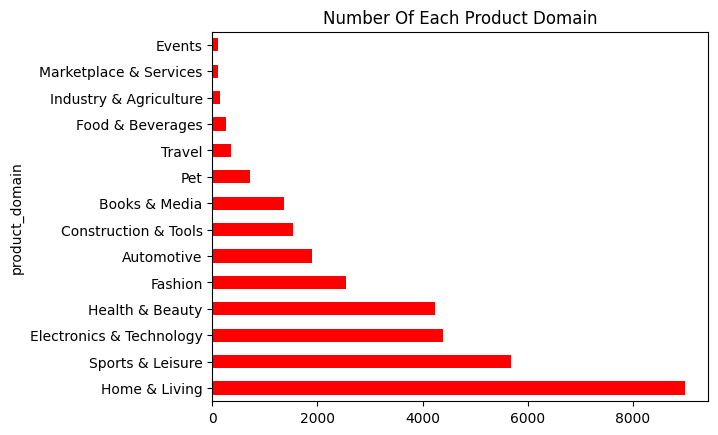

In [87]:
products['product_domain'].dropna().value_counts(dropna=False).plot(kind = "barh" , color ="red")
plt.title("Number Of Each Product Domain")

In [88]:
#  Orders Summary
order_items_summary = order_items.groupby('order_id').agg(
    gross_revenue=('price', 'sum'),
    total_freight_value=('freight_value', 'sum'),
    num_items=('order_item_id', 'count'),
    num_distinct_products=('product_id', 'nunique'),
    num_distinct_sellers=('seller_id', 'nunique')
).reset_index()

order_items_summary.head()

,order_id,gross_revenue,total_freight_value,num_items,num_distinct_products,num_distinct_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,1,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,1,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,1,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,1,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,1,1


In [89]:
# Payment Summary
payments_summary = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    num_payment_methods=('payment_type', 'nunique'),
    max_installments=('payment_installments', 'max')
).reset_index()
payments_summary.head()

,order_id,total_payment_value,num_payment_methods,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,1,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,1,3
2,000229ec398224ef6ca0657da4fc703e,216.87,1,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,1,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,1,3


# **Data Merging**

In [90]:
df = orders.merge(customers, on='customer_id', how='left')
df = df.merge(order_items_summary, on='order_id', how='left')
df = df.merge(payments_summary, on='order_id', how='left')
df = df.merge(reviews_dedup, on='order_id', how='left')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_season,...,num_distinct_sellers,total_payment_value,num_payment_methods,max_installments,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,10,Spring,...,1.0,38.71,2.0,1.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,7,Winter,...,1.0,141.46,1.0,1.0,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,8,Winter,...,1.0,179.12,1.0,3.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,None,None,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,11,Spring,...,1.0,72.20,1.0,1.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,None,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,Summer,...,1.0,28.62,1.0,1.0,e50934924e227544ba8246aeb3770dd4,5.0,None,None,2018-02-17,2018-02-18 13:02:51


In [91]:
order_seller_state = (
    order_items.merge(sellers[['seller_id','seller_state']], on='seller_id', how='left')
    .groupby('order_id')['seller_state']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={'seller_state': 'primary_seller_state'})
)


In [92]:
order_seller_state.head()

,order_id,primary_seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,SP
1,00018f77f2f0320c557190d7a144bdd3,SP
2,000229ec398224ef6ca0657da4fc703e,MG
3,00024acbcdf0a6daa1e931b038114c75,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,PR


In [93]:
order_product_domain = (
    order_items.merge(products[['product_id','product_domain']], on='product_id', how='left')
    .groupby('order_id')['product_domain']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
    .rename(columns={'product_domain': 'primary_product_domain'}) )

In [94]:
order_product_domain.head()

,order_id,primary_product_domain
0,00010242fe8c5a6d1ba2dd792cb16214,Sports & Leisure
1,00018f77f2f0320c557190d7a144bdd3,Pet
2,000229ec398224ef6ca0657da4fc703e,Home & Living
3,00024acbcdf0a6daa1e931b038114c75,Health & Beauty
4,00042b26cf59d7ce69dfabb4e55b4fd9,Construction & Tools


In [95]:
df = df.merge(order_seller_state, on='order_id', how='left')
df = df.merge(order_product_domain, on='order_id', how='left')

In [96]:
#df.to_csv(r'row_orders.csv', index=False)

In [97]:
print("Total rows in df:", len(df))
print("Total rows in orders (should match):", len(orders))
print()

print("Missing gross_revenue (order with no items?):", df['gross_revenue'].isna().sum())
print("Missing total_payment_value (order with no payment?):", df['total_payment_value'].isna().sum())
print("Missing customer info:", df['customer_city'].isna().sum())
print()

print("Duplicate order_id in final df:", df['order_id'].duplicated().sum())

Total rows in df: 99441
Total rows in orders (should match): 99441

Missing gross_revenue (order with no items?): 775
Missing total_payment_value (order with no payment?): 1
Missing customer info: 0

Duplicate order_id in final df: 0


# **Full Data Set**

In [98]:
data = df.copy()

## Data Exploration

In [99]:
data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_season,...,num_payment_methods,max_installments,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,primary_seller_state,primary_product_domain
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,10,Spring,...,2.0,1.0,a54f0611adc9ed256b57ede6b6eb5114,4.0,None,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,SP,Home & Living
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,7,Winter,...,1.0,1.0,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,SP,Health & Beauty
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,8,Winter,...,1.0,3.0,e73b67b67587f7644d5bd1a52deb1b01,5.0,None,None,2018-08-18,2018-08-22 19:07:58,SP,Automotive
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,11,Spring,...,1.0,1.0,359d03e676b3c069f62cadba8dd3f6e8,5.0,None,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,MG,Pet
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,Summer,...,1.0,1.0,e50934924e227544ba8246aeb3770dd4,5.0,None,None,2018-02-17,2018-02-18 13:02:51,SP,Books & Media


In [100]:
data.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_season,...,num_payment_methods,max_installments,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,primary_seller_state,primary_product_domain
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,3,Autumn,...,1.0,3.0,e262b3f92d1ce917aa412a9406cf61a6,5.0,None,None,2017-03-22,2017-03-23 11:02:08,SP,Health & Beauty
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2,Summer,...,1.0,3.0,29bb71b2760d0f876dfa178a76bc4734,4.0,None,So uma peça que veio rachado mas tudo bem rs,2018-03-01,2018-03-02 17:50:01,SP,Health & Beauty
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,8,Winter,...,1.0,5.0,371579771219f6db2d830d50805977bb,5.0,None,Foi entregue antes do prazo.,2017-09-22,2017-09-22 23:10:57,SP,Electronics & Technology
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,Summer,...,1.0,4.0,8ab6855b9fe9b812cd03a480a25058a1,2.0,None,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,MG,Electronics & Technology
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03,3,Autumn,...,1.0,1.0,dc9c59b4688062c25758c2be4cafc523,5.0,None,None,2018-03-17,2018-03-17 16:33:31,SP,Health & Beauty


In [101]:
data.shape

(99441, 40)

In [102]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       99441 non-null  object         
 1   customer_id                    99441 non-null  object         
 2   order_status                   99441 non-null  category       
 3   order_purchase_timestamp       99441 non-null  datetime64[ns] 
 4   order_approved_at              99281 non-null  datetime64[ns] 
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns] 
 6   order_delivered_customer_date  96476 non-null  datetime64[ns] 
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns] 
 8   order_month                    99441 non-null  int32          
 9   order_season                   99441 non-null  object         
 10  order_weekday                  99441 non-null  int32          
 11  or

In [103]:
data.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_weekday,order_hour,order_delay,order_delay_days,...,total_freight_value,num_items,num_distinct_products,num_distinct_sellers,total_payment_value,num_payment_methods,max_installments,review_score,review_creation_date,review_answer_timestamp
count,99441,99281,97658,96476,99441,99441.000000,99441.000000,99441.000000,96476,96476.000000,...,98666.000000,98666.000000,98666.000000,98666.000000,99440.000000,99440.000000,99440.000000,98673.000000,98673,98673
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,6.032220,2.755735,14.770829,-12 days +19:42:04.042383598,-11.876881,...,22.823562,1.141731,1.038098,1.013622,160.990267,1.022586,2.930521,4.086184,2018-01-13 04:44:29.763765248,2018-01-16 08:19:52.283015424
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,0.000000,0.000000,-147 days +23:36:47,-147.000000,...,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,2016-10-02 00:00:00,2016-10-07 18:32:28
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,3.000000,1.000000,11.000000,-17 days +18:08:05.250000,-17.000000,...,13.850000,1.000000,1.000000,1.000000,62.010000,1.000000,1.000000,4.000000,2017-09-23 00:00:00,2017-09-27 14:50:01
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,6.000000,3.000000,15.000000,-12 days +01:13:31.500000,-12.000000,...,17.170000,1.000000,1.000000,1.000000,105.290000,1.000000,2.000000,5.000000,2018-02-02 00:00:00,2018-02-05 10:51:54
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,8.000000,4.000000,19.000000,-7 days +14:38:24,-7.000000,...,24.040000,1.000000,1.000000,1.000000,176.970000,1.000000,4.000000,5.000000,2018-05-16 00:00:00,2018-05-20 14:01:07
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,12.000000,6.000000,23.000000,188 days 23:24:07,188.000000,...,1794.960000,21.000000,8.000000,5.000000,13664.080000,2.000000,24.000000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,NaN,NaN,NaN,NaN,NaN,3.232999,1.966495,5.326800,10 days 04:28:00.181984555,10.183854,...,21.650909,0.538452,0.226456,0.122297,221.951257,0.148582,2.715685,1.347721,NaN,NaN


In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
df.dtypes

order_id                                  object
customer_id                               object
order_status                            category
order_purchase_timestamp          datetime64[ns]
order_approved_at                 datetime64[ns]
order_delivered_carrier_date      datetime64[ns]
order_delivered_customer_date     datetime64[ns]
order_estimated_delivery_date     datetime64[ns]
order_month                                int32
order_season                              object
order_weekday                              int32
order_hour                                 int32
order_delay                      timedelta64[ns]
order_delay_days                         float64
is_late                                    int64
is_weekend                                 int64
customer_order_seq                         int64
is_repeat_customer                         int64
lead_time_days                           float64
expected_delivery_days                     int64
customer_unique_id  

In [106]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  160
order_delivered_carrier_date      1783
order_delivered_customer_date     2965
order_estimated_delivery_date        0
order_month                          0
order_season                         0
order_weekday                        0
order_hour                           0
order_delay                       2965
order_delay_days                  2965
is_late                              0
is_weekend                           0
customer_order_seq                   0
is_repeat_customer                   0
lead_time_days                    3156
expected_delivery_days               0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
gross_revenue                      775
total_freight_value      

In [107]:
pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isnull().sum().values,
    "Missing Percentage": (df.isnull().sum().values / df.shape[0]) * 100
})

,Column,Missing Count,Missing Percentage
0,order_id,0,0.000000
1,customer_id,0,0.000000
2,order_status,0,0.000000
3,order_purchase_timestamp,0,0.000000
4,order_approved_at,160,0.160899
5,order_delivered_carrier_date,1783,1.793023
6,order_delivered_customer_date,2965,2.981668
7,order_estimated_delivery_date,0,0.000000
8,order_month,0,0.000000
9,order_season,0,0.000000


In [108]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_month', 'order_season', 'order_weekday', 'order_hour',
       'order_delay', 'order_delay_days', 'is_late', 'is_weekend',
       'customer_order_seq', 'is_repeat_customer', 'lead_time_days',
       'expected_delivery_days', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'gross_revenue', 'total_freight_value', 'num_items',
       'num_distinct_products', 'num_distinct_sellers', 'total_payment_value',
       'num_payment_methods', 'max_installments', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'primary_seller_state', 'primary_product_domain'],
      dtype='object')

In [109]:
# Used Data
# Drop features that may cause data leakage or are not relevant to the prediction task.
dff = data.drop(columns = ["order_purchase_timestamp","order_approved_at","order_delivered_customer_date","order_estimated_delivery_date",
                           "order_delivered_carrier_date" , "order_delay", "order_delay_days", "order_status",
                           "review_id","review_score","review_comment_title", "review_comment_message" , "review_creation_date",
                           "review_answer_timestamp" ,"lead_time_days", "customer_zip_code_prefix","gross_revenue" ,
                           "max_installments", "num_payment_methods"])

In [110]:
dff.head()

,order_id,customer_id,order_month,order_season,order_weekday,order_hour,is_late,is_weekend,customer_order_seq,is_repeat_customer,...,customer_unique_id,customer_city,customer_state,total_freight_value,num_items,num_distinct_products,num_distinct_sellers,total_payment_value,primary_seller_state,primary_product_domain
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,10,Spring,0,10,0,0,1,1,...,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,8.72,1.0,1.0,1.0,38.71,SP,Home & Living
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,7,Winter,1,20,0,0,0,0,...,af07308b275d755c9edb36a90c618231,barreiras,BA,22.76,1.0,1.0,1.0,141.46,SP,Health & Beauty
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,8,Winter,2,8,0,0,0,0,...,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,19.22,1.0,1.0,1.0,179.12,SP,Automotive
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,11,Spring,5,19,0,1,0,0,...,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,27.20,1.0,1.0,1.0,72.20,MG,Pet
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2,Summer,1,21,0,0,0,0,...,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,8.72,1.0,1.0,1.0,28.62,SP,Books & Media


In [111]:
dff.shape

(99441, 21)

In [112]:
dff.columns

Index(['order_id', 'customer_id', 'order_month', 'order_season',
       'order_weekday', 'order_hour', 'is_late', 'is_weekend',
       'customer_order_seq', 'is_repeat_customer', 'expected_delivery_days',
       'customer_unique_id', 'customer_city', 'customer_state',
       'total_freight_value', 'num_items', 'num_distinct_products',
       'num_distinct_sellers', 'total_payment_value', 'primary_seller_state',
       'primary_product_domain'],
      dtype='object')

In [113]:
dff.isna().sum()

order_id                     0
customer_id                  0
order_month                  0
order_season                 0
order_weekday                0
order_hour                   0
is_late                      0
is_weekend                   0
customer_order_seq           0
is_repeat_customer           0
expected_delivery_days       0
customer_unique_id           0
customer_city                0
customer_state               0
total_freight_value        775
num_items                  775
num_distinct_products      775
num_distinct_sellers       775
total_payment_value          1
primary_seller_state       775
primary_product_domain    2164
dtype: int64

In [114]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   order_id                99441 non-null  object  
 1   customer_id             99441 non-null  object  
 2   order_month             99441 non-null  int32   
 3   order_season            99441 non-null  object  
 4   order_weekday           99441 non-null  int32   
 5   order_hour              99441 non-null  int32   
 6   is_late                 99441 non-null  int64   
 7   is_weekend              99441 non-null  int64   
 8   customer_order_seq      99441 non-null  int64   
 9   is_repeat_customer      99441 non-null  int64   
 10  expected_delivery_days  99441 non-null  int64   
 11  customer_unique_id      99441 non-null  object  
 12  customer_city           99441 non-null  category
 13  customer_state          99441 non-null  category
 14  total_freight_value   

### Fixing Data types

In [115]:
col = dff.select_dtypes(include=['object']).columns
dff[col] = dff[col].astype('category')

In [116]:
dff.dtypes

order_id                  category
customer_id               category
order_month                  int32
order_season              category
order_weekday                int32
order_hour                   int32
is_late                      int64
is_weekend                   int64
customer_order_seq           int64
is_repeat_customer           int64
expected_delivery_days       int64
customer_unique_id        category
customer_city             category
customer_state            category
total_freight_value        float64
num_items                  float64
num_distinct_products      float64
num_distinct_sellers       float64
total_payment_value        float64
primary_seller_state      category
primary_product_domain    category
dtype: object

### Handlig Null values

In [117]:
pd.DataFrame({
    "Column": dff.columns,
    "Missing Count": dff.isnull().sum().values,
    "Missing Percentage": (dff.isnull().sum().values / dff.shape[0]) * 100
})

,Column,Missing Count,Missing Percentage
0,order_id,0,0.000000
1,customer_id,0,0.000000
2,order_month,0,0.000000
3,order_season,0,0.000000
4,order_weekday,0,0.000000
5,order_hour,0,0.000000
6,is_late,0,0.000000
7,is_weekend,0,0.000000
8,customer_order_seq,0,0.000000
9,is_repeat_customer,0,0.000000


total_freight_value, num_items, num_distinct_products, and total_payment_value each have less than 1% missing values. These nulls occur because some order_ids have no corresponding records in the related summary tables.

In [118]:
dff = dff[~dff["total_freight_value"].isna()]


In [119]:
missing_order_ids = dff.loc[
    dff["total_payment_value"].isna(),
    "order_id"
]

payments[payments["order_id"].isin(missing_order_ids)]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [120]:
dff = dff.dropna(subset=['total_payment_value'])

In [121]:
dff["primary_product_domain"].unique()

['Home & Living', 'Health & Beauty', 'Automotive', 'Pet', 'Books & Media', ..., 'Food & Beverages', 'Events', 'Travel', 'Marketplace & Services', 'Industry & Agriculture']
Length: 15
Categories (14, object): ['Automotive', 'Books & Media', 'Construction & Tools', 'Electronics & Technology', ..., 'Marketplace & Services', 'Pet', 'Sports & Leisure', 'Travel']

In [122]:
dff["primary_product_domain"] = (
    dff["primary_product_domain"]
    .cat.add_categories("Other")
    .fillna("Other")
)

In [123]:
dff.isnull().sum()

order_id                  0
customer_id               0
order_month               0
order_season              0
order_weekday             0
order_hour                0
is_late                   0
is_weekend                0
customer_order_seq        0
is_repeat_customer        0
expected_delivery_days    0
customer_unique_id        0
customer_city             0
customer_state            0
total_freight_value       0
num_items                 0
num_distinct_products     0
num_distinct_sellers      0
total_payment_value       0
primary_seller_state      0
primary_product_domain    0
dtype: int64

In [124]:
dff.to_csv(r'clean_orders.csv', index=False)

### Unique Values For All Categories

In [125]:
cat_col = [
    col for col in dff.select_dtypes(include="category").columns
    if col not in ["order_id", "customer_id", "customer_unique_id"]
]

for col in cat_col:
  print (f"{col} unique values are {dff[col].unique()}")
  print()
  print("*" *130)
  print()


order_season unique values are ['Spring', 'Winter', 'Summer', 'Autumn']
Categories (4, object): ['Autumn', 'Spring', 'Summer', 'Winter']

**********************************************************************************************************************************

customer_city unique values are ['sao paulo', 'barreiras', 'vianopolis', 'sao goncalo do amarante', 'santo andre', ..., 'pacuja', 'umburanas', 'messias targino', 'campo do tenente', 'nova vicosa']
Length: 4110
Categories (4119, object): ['abadia dos dourados', 'abadiania', 'abaete', 'abaetetuba', ..., 'xique-xique', 'zacarias', 'ze doca', 'zortea']

**********************************************************************************************************************************

customer_state unique values are ['SP', 'BA', 'GO', 'RN', 'PR', ..., 'MA', 'PI', 'AL', 'AC', 'AM']
Length: 27
Categories (27, object): ['AC', 'AL', 'AM', 'AP', ..., 'SC', 'SE', 'SP', 'TO']

********************************************************

# **EDA**

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Outliers Visualizations

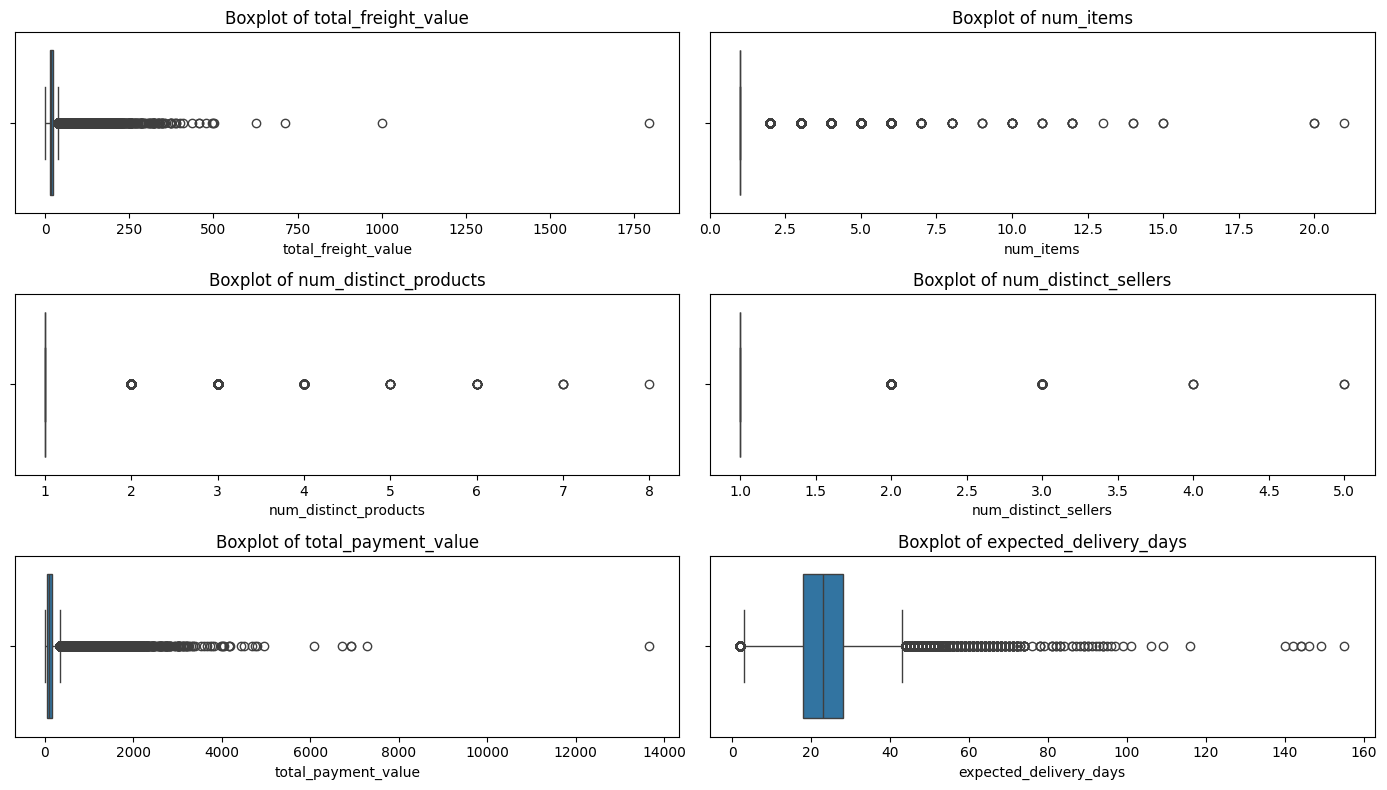

In [127]:
# Outlier values can be valid, so we keep them.

numeric_cols = [
    'total_freight_value',
    'num_items',
    'num_distinct_products',
    "num_distinct_sellers",
    'total_payment_value',
    'expected_delivery_days']

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 8)
)

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(x=dff[col], ax=ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight 
- **What happened?** Several numerical features show strong right-skewness and extreme values. `total_freight_value` reaches approximately **1,800**, `total_payment_value` exceeds **13,000**, `num_items` reaches **21**, and `expected_delivery_days` has a long tail reaching approximately **155 days**, while its median is around **23 days**.
- **ML meaning:** Strongly skewed features and extreme values may affect models that are sensitive to feature scale and distance. Log transformations such as `log1p`, robust scaling, or tree-based models can help reduce the impact of extreme values.
- **Business meaning:** Extreme orders may represent unusual purchasing patterns, large baskets, or geographically challenging shipments. These cases may require different fulfillment and delivery strategies.
- **Action / recommendation:** Monitor extreme orders separately and consider creating risk indicators for unusually high `expected_delivery_days`, `num_items`, or freight values. These cases can be prioritized for additional logistics monitoring.
- **Limitation:** Extreme values may represent legitimate but rare transactions rather than data errors. Removing them completely could cause the model to miss important high-risk cases.

### Target distribution

In [128]:
target_counts = dff['is_late'].value_counts().reset_index()
target_counts.columns = ['is_late', 'count']

target_counts['is_late'] = target_counts['is_late'].map({
    0: 'Not Late',
    1: 'Late'
})

fig = px.pie(
    target_counts,
    names='is_late',
    values='count',
    title='Target Distribution - Is Late',
    hole=0.3
)

fig.update_layout(
    width=1000,
    height=650,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.update_traces(textinfo='percent+label')
fig.show()

impalanced class

### Insight 
- **What happened?** The target variable `is_late` is highly imbalanced, with approximately **92.1% non-late orders** and only **7.93% late orders**, representing roughly an **11.6:1 ratio**.
- **ML meaning:** Accuracy alone is not sufficient for evaluating the model because a naive classifier that predicts every order as non-late could achieve approximately **92.1% accuracy** without detecting any late orders. Metrics such as **Recall, Precision, F1-score, ROC-AUC, and PR-AUC** are more informative for the minority class.
- **Business meaning:** Although late orders represent a relatively small proportion of all orders, identifying them is important because delays can negatively affect customer satisfaction and operational performance.
- **Action / recommendation:** Prioritize **Recall** when selecting the classification threshold if the business goal is to identify as many potentially late orders as possible. This can help the business intervene earlier, while balancing the number of false alarms.
- **Limitation:** The binary target only indicates whether an order was late or not. It does not distinguish between a **minor delay** and a **severe delay**, which may have very different business impacts.

## Correlation Heatmap

In [129]:

numeric_cols = dff.select_dtypes(include='number').columns

corr = dff[numeric_cols].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    aspect='auto',
    title='Correlation Matrix'
)

fig.show()

### Insight 
- **What happened?** The linear correlation between `is_late` and the numerical features is generally weak, with absolute correlation values of approximately **|r| ≤ 0.06**. However, some features show stronger correlations with each other, including `is_weekend` and `order_weekday` (**r ≈ 0.77**), `customer_order_seq` and `is_repeat_customer` (**r ≈ 0.82**), and `num_distinct_sellers` and `num_distinct_products` (**r ≈ 0.59**).
- **ML meaning:** Weak Pearson correlations do not necessarily mean that the features have no predictive value because non-linear relationships and feature interactions may exist. Highly correlated features may provide redundant information, so feature selection or feature engineering should be considered.
- **Business meaning:** Late delivery does not appear to be strongly associated with any single numerical feature. Delivery performance may depend on a combination of factors such as geography, seasonality, seller characteristics, and logistics conditions.
- **Action / recommendation:** Explore interaction and derived features such as seller-to-customer geographic distance, freight-to-payment ratio, and seasonal indicators. For highly correlated feature pairs, consider removing redundant variables when using models that are sensitive to multicollinearity.
- **Limitation:** Pearson correlation measures **linear relationships only**. It does not capture non-linear patterns, threshold effects, or interactions between categorical and numerical variables.

## Orders Over Time

In [130]:
monthly_orders = (
    dff['order_month']
    .value_counts()
    .sort_index()
    .reset_index()
)

monthly_orders.columns = ['month', 'orders']

fig = px.line(
    monthly_orders,
    x='month',
    y='orders',
    markers=True,
    title='Orders by Month'
)

fig.update_xaxes(dtick=1)
#plt.savefig('orders_by_month.png', dpi=300, bbox_inches='tight')

fig.show()

### Insight — Orders by Month
- **What happened?** Order volume remains relatively steady from January through August, ranging from approximately **8K to 10.8K orders**, with a peak of around **10.8K in August**. This is followed by a sharp decline in September and October, reaching approximately **4.2K and 4.9K orders**, before partially recovering in November to around **7.5K orders**.
- **ML meaning:** Month and season may capture temporal patterns in the data. However, raw monthly volume should not be interpreted as delivery risk by itself, and temporal features should be handled carefully to avoid temporal bias or data leakage when splitting the dataset.
- **Business meaning:** Order volume varies substantially across months, which can affect fulfillment workload, transportation demand, and logistics capacity.
- **Action / recommendation:** Use historical demand patterns to plan fulfillment capacity, staffing, and carrier resources during high-volume periods. However, operational planning should account for the incomplete data in the later months.
- **Limitation:** The sharp decline after August is likely influenced by the **incomplete data coverage in the later months of the Olist dataset**, so it should not be interpreted as a true decline in customer demand.

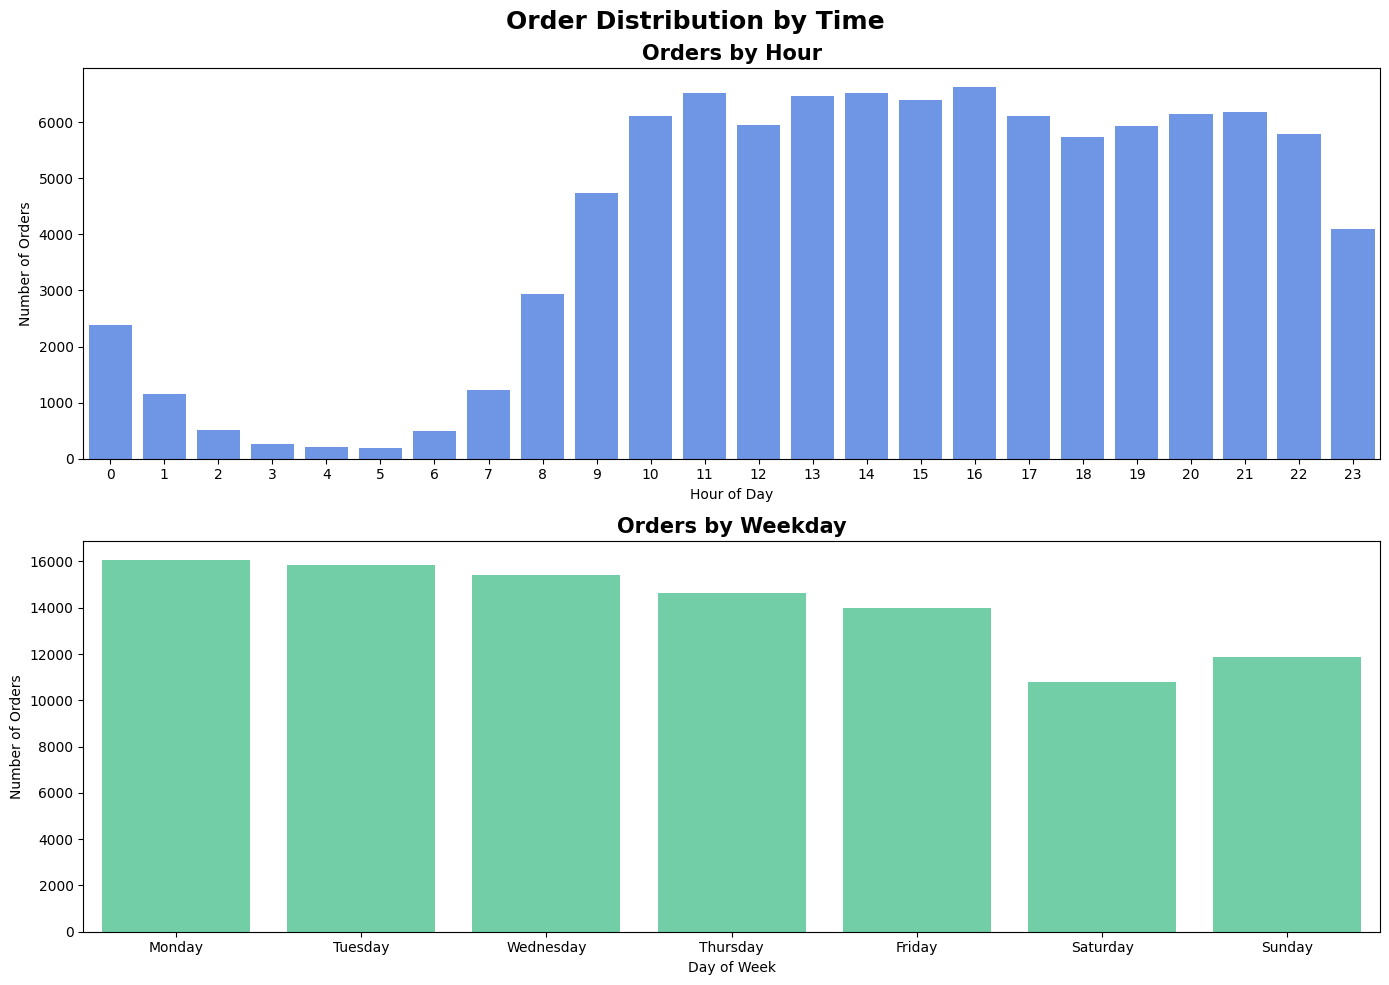

In [194]:
# Orders by Hour
hourly_orders = (
    dff['order_hour']
    .value_counts()
    .sort_index()
    .reset_index()
)

hourly_orders.columns = ['hour', 'orders']


# Orders by Weekday
weekday_orders = (
    dff['order_weekday']
    .value_counts()
    .sort_index()
    .reset_index()
)

weekday_orders.columns = ['weekday', 'orders']

weekday_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

weekday_orders['weekday'] = weekday_orders['weekday'].map(weekday_map)


# Subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Hour chart
sns.barplot(
    data=hourly_orders,
    x='hour',
    y='orders',
    color='#5B8FF9',
    ax=axes[0]
)

axes[0].set_title('Orders by Hour', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Orders')


# Weekday chart
sns.barplot(
    data=weekday_orders,
    x='weekday',
    y='orders',
    color='#61DDAA',
    ax=axes[1]
)

axes[1].set_title('Orders by Weekday', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Orders')


plt.suptitle('Order Distribution by Time', fontsize=18, fontweight='bold')
plt.tight_layout()

plt.savefig('weekday&timeDistribution.png', dpi=300, bbox_inches='tight')

plt.show()

### Insight 
- **What happened?** Hourly order volume increases sharply from around **08:00 (~3K orders)** and remains high between **10:00 and 22:00**, with approximately 
**6K–6.7K orders per hour** and a peak around **16:00**. Order volume is lowest between **02:00 and 06:00**, with fewer than **500 orders per hour**. By weekday, order volume is highest on **Monday (~16K)** 
and gradually decreases through the week, reaching its lowest level on **Saturday (~10.8K)** before increasing again on Sunday (~11.9K).
- **ML meaning:** Time-based features may capture temporal patterns in customer ordering behavior. `order_hour` should not be treated as a simple linear variable because the relationship between hour and delivery behavior may be non-linear. Cyclical encoding using **sin/cos transformations** or categorical/peak-hour features can better represent hourly patterns.
- **Business meaning:** Customer demand is concentrated during daytime and evening hours, while order activity is much lower overnight. Weekday demand is also higher than weekend demand, creating different operational workloads throughout the week.
- **Action / recommendation:** Align fulfillment, customer service, and carrier capacity with peak ordering periods. In particular, ensure sufficient operational capacity during **10:00–22:00** and review carrier handover schedules for orders placed toward the end of the working week.
- **Limitation:** The chart shows **order placement volume**, not actual seller processing, fulfillment, or carrier pickup times. Therefore, it cannot directly establish that orders placed at specific hours or weekdays are more likely to be delayed.

## Distribution of Numnerical Columns

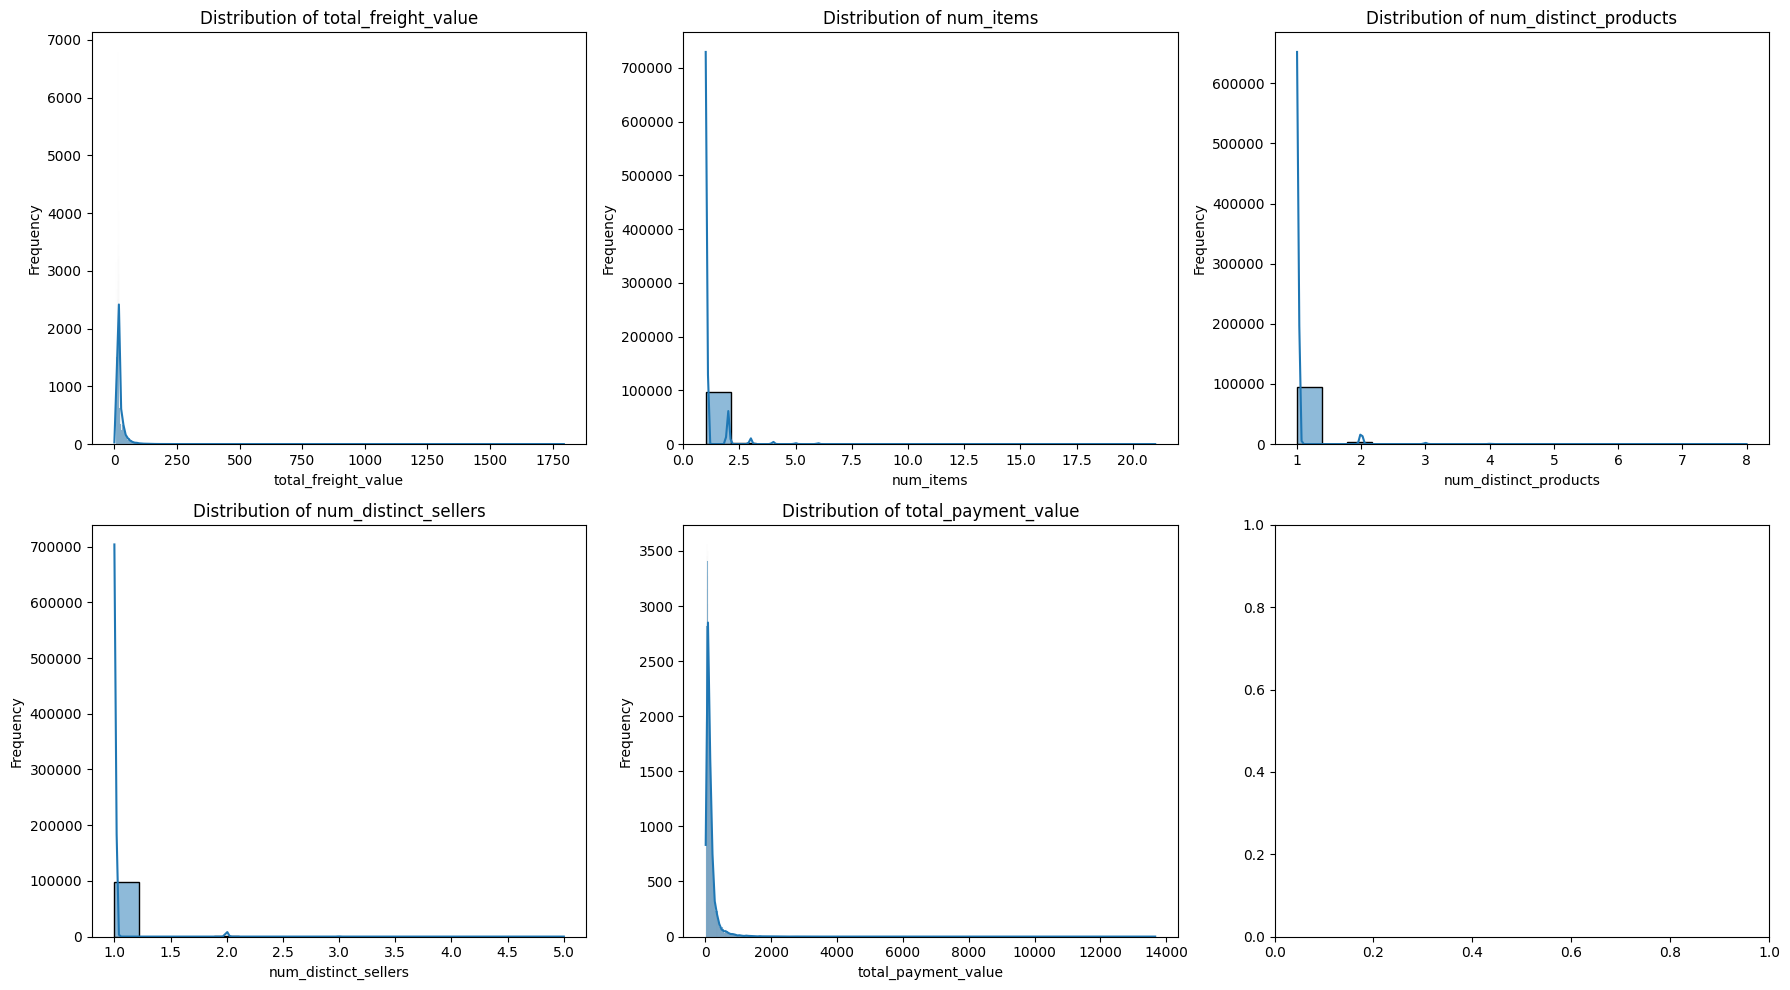

In [193]:
numeric_cols = [
    'total_freight_value',
    'num_items',
    'num_distinct_products',
    "num_distinct_sellers",
    'total_payment_value'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(
        data=dff,
        x=col,
        kde=True,
        ax=ax
    )
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('numerical_features_diatribution.png', dpi=300, bbox_inches='tight')

plt.show()

###  The numerical features are highly right-skewed. The extreme values were inspected and found to be valid observations, so they were retained rather than removed.

### Insight 
- **What happened?** `total_freight_value`, `num_items`, `num_distinct_products`, `num_distinct_sellers`, and `total_payment_value` are strongly **right-skewed**.
 Most orders contain **one item, one distinct product, and one seller**, while larger orders are much less frequent.
- **ML meaning:** The strong skewness and presence of extreme values should be considered during preprocessing. Tree-based models are generally less sensitive to scaling, while linear models may benefit from transformations such as `log1p` and robust scaling.
- **Business meaning:** The typical order is relatively simple, while complex or high-value orders are uncommon. Unusual large orders may require different operational handling.
- **Action / recommendation:** Monitor extreme-value orders separately and consider appropriate transformations for highly skewed numerical features before training models that are sensitive to distributions and outliers.
- **Limitation:** These distributions describe the overall order population, not specifically the relationship between these variables and late delivery. Further comparison between late and non-late orders is needed.

## Total Payment by Category

C:\Users\Vista Store\AppData\Local\Temp\ipykernel_9700\1736407338.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


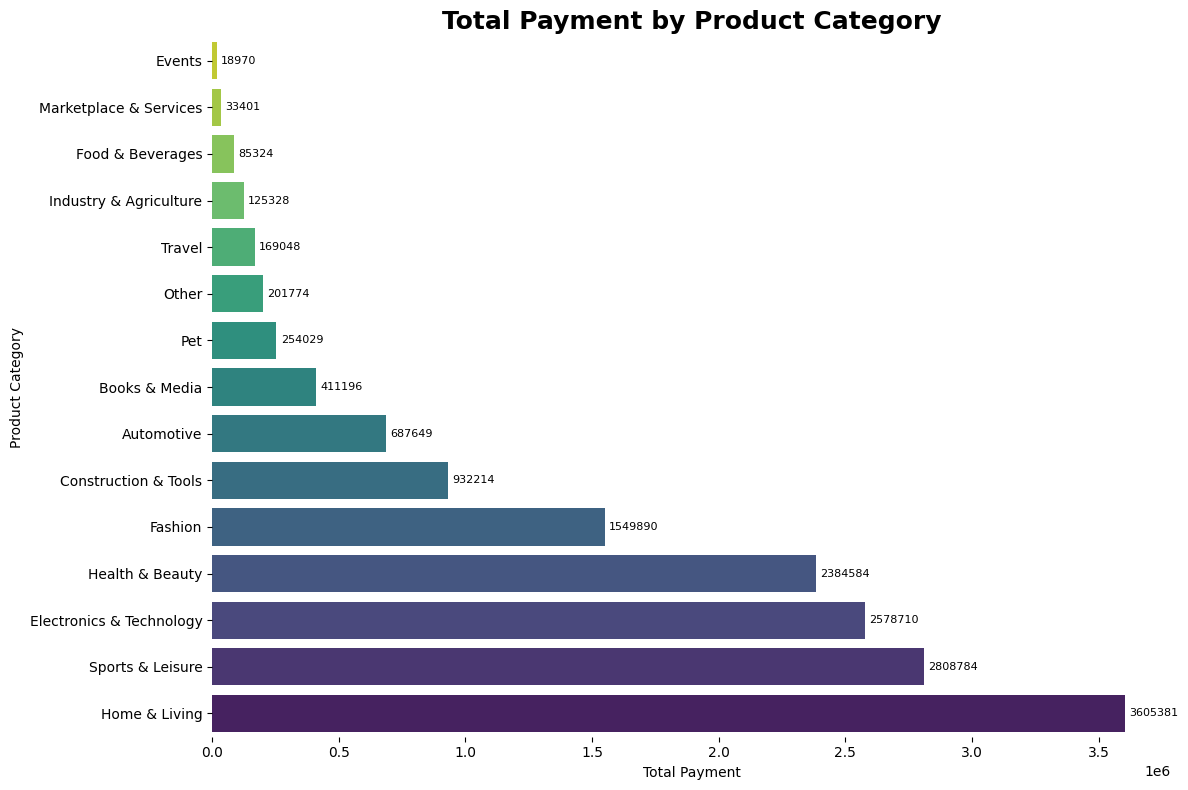

In [133]:
plt.figure(figsize=(12, 8))

payment_by_category = (
    dff.groupby('primary_product_domain', observed=True)['total_payment_value']
       .sum()
       .sort_values(ascending=False)
       .reset_index()
)

order = payment_by_category['primary_product_domain']

ax = sns.barplot(
    data=payment_by_category,
    x='total_payment_value',
    y='primary_product_domain',
    order=order,
    palette='viridis'
)

ax.invert_yaxis()

plt.title(
    'Total Payment by Product Category',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Total Payment')
plt.ylabel('Product Category')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3,
        fontsize=8
    )

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('payment_by_category.png', dpi=300, bbox_inches='tight')

plt.show()

### Insight 
- **What happened?** **Home & Living** generates the highest total payment value at approximately **3.61M**, followed by **Sports & Leisure (~2.81M)**, **Electronics & Technology (~2.58M)**,
 and **Health & Beauty (~2.38M)**. **Events** has the lowest total at approximately **18.9K**.
- **ML meaning:** `primary_product_domain` may provide useful information for the model because product categories can differ in shipping requirements, order volume, and logistics characteristics.
- **Business meaning:** Home & Living, Sports & Leisure, Electronics & Technology, and Health & Beauty are important payment-generating categories and therefore deserve stronger operational monitoring.
- **Action / recommendation:** Prioritize inventory and logistics planning for high-value categories and investigate whether these categories also have higher late-delivery rates before making operational changes.
- **Limitation:** Total payment reflects both order volume and order value. It does not directly measure profitability or delivery performance, and the chart alone cannot establish that a product category causes delays.

##

## Total Payments By Customer State

In [134]:
payment_by_state = (
    dff.groupby('customer_state', as_index=False)['total_payment_value']
    .sum()
    .rename(columns={'total_payment_value': 'total_payment'})
)

fig = px.choropleth(
    payment_by_state,
    geojson="https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson",
    locations="customer_state",
    featureidkey="properties.sigla",
    color="total_payment",
    color_continuous_scale="Blues",
    scope="south america",
    title="Total Payment by Customer State"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    width=800,
    height=650,
    margin=dict(l=0, r=0, t=60, b=0)
)

plt.savefig('payment_by_customer_state.png', dpi=300, bbox_inches='tight')

fig.show()

C:\Users\Vista Store\AppData\Local\Temp\ipykernel_9700\2592025853.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff.groupby('customer_state', as_index=False)['total_payment_value']


<Figure size 640x480 with 0 Axes>

### Insight 
- **What happened?** Total payment is geographically concentrated, with **São Paulo (SP)** showing the highest total payment value, followed by other major states such as **Rio de Janeiro (RJ)**.
- **ML meaning:** `customer_state` may capture geographic differences in customer activity and order volume. However, total payment should not automatically be interpreted as a predictor of late delivery.
- **Business meaning:** A large portion of the business's payment volume is concentrated in a small number of customer states, making these markets strategically important.
- **Action / recommendation:** Prioritize logistics capacity, inventory availability, and delivery performance monitoring in high-value and high-volume customer states.
- **Limitation:** High total payment may simply reflect a larger number of orders rather than higher spending per customer. The map does not show late-delivery rates, so it cannot determine whether high-value states experience more delays.

## Late Orders By Season

C:\Users\Vista Store\AppData\Local\Temp\ipykernel_9700\650029131.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff.groupby('order_season')['is_late']


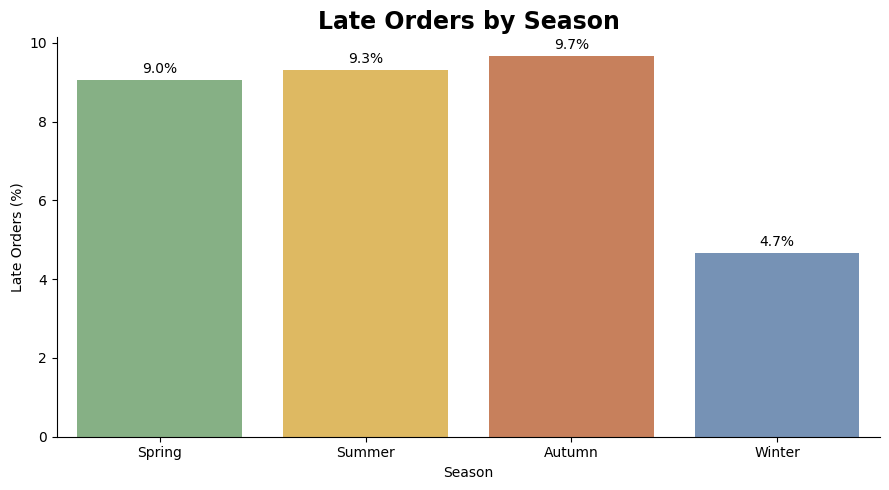

In [135]:
season_delay = (
    dff.groupby('order_season')['is_late']
    .mean()
    .reset_index()
)
season_delay['late_percentage'] = season_delay['is_late'] * 100

order = ['Spring', 'Summer', 'Autumn', 'Winter']

season_colors = {
    'Spring': '#7FB77E',
    'Summer': '#F2C14E',
    'Autumn': '#D97A4A',
    'Winter': '#6C91BF'
}

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=season_delay,
    x='order_season',
    y='late_percentage',
    order=order,
    hue='order_season',
    palette=season_colors,
    legend=False
)

plt.title('Late Orders by Season', fontsize=17, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Late Orders (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig('late_orders_by_season.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight 
- **What happened?** **Autumn** has the highest late-order rate at approximately **9.7%**, followed by **Summer (9.3%)** and **Spring (9.0%)**. **Winter** has the lowest rate at approximately **4.7%**.
- **ML meaning:** `order_season` may be a useful categorical feature because delivery performance varies across seasons. It can help the model capture seasonal patterns in delivery delays.
- **Business meaning:** Delivery operations appear to experience higher delay rates during Autumn and Summer compared with Winter.
- **Action / recommendation:** Increase logistics monitoring and capacity planning during higher-risk seasons, particularly Autumn. Investigate whether demand, transportation conditions, or operational capacity contribute to the seasonal differences.
- **Limitation:** Season is associated with the observed delay rate but does not explain why the difference occurs. Other factors may vary between seasons.

## Average Expected Delivery Days by Delay Satus


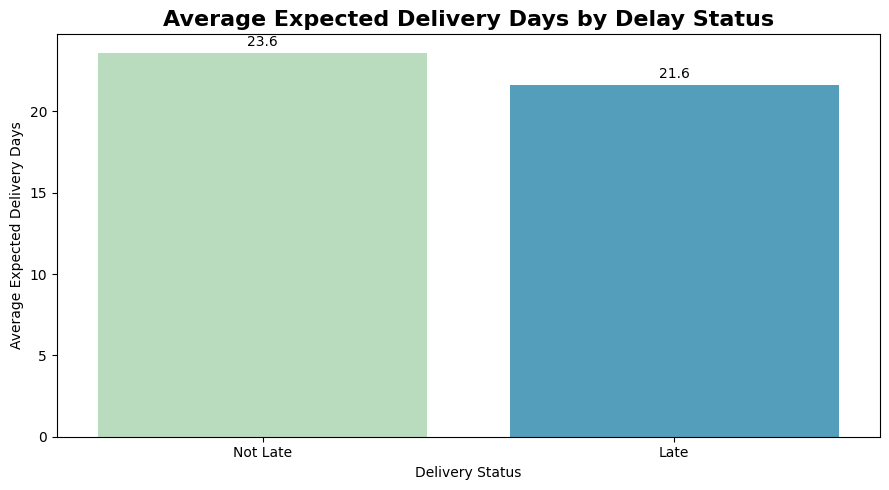

In [136]:
plt.figure(figsize=(9, 5))

expected_delay = (
    dff.groupby('is_late')['expected_delivery_days']
       .mean()
       .reset_index()
)

expected_delay['status'] = expected_delay['is_late'].map({
    0: 'Not Late',
    1: 'Late'
})

ax = sns.barplot(
    data=expected_delay,
    x='status',
    y='expected_delivery_days',
    hue='status',
    palette='GnBu',
    legend=False
)

plt.title('Average Expected Delivery Days by Delay Status',
          fontsize=16, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Average Expected Delivery Days')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.savefig('Average_expexted_delay.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
- **What happened?** The average expected delivery period is **23.6 days for non-late orders** compared with **21.6 days for late orders**. Late orders therefore have an average expected delivery window about **2 days shorter**.
- **ML meaning:** `expected_delivery_days` may be an informative feature because shorter promised delivery windows appear to be associated with late deliveries. The relationship should be validated by the model rather than assumed to be linear.
- **Business meaning:** Some delays may occur when delivery expectations are relatively aggressive, suggesting that promised delivery dates may sometimes be too optimistic.
- **Action / recommendation:** Review estimated delivery times and consider using historical delivery performance when setting customer-facing delivery estimates.
- **Limitation:** This comparison is observational and does not prove that shorter delivery estimates cause delays. Other factors such as seller location, customer location, carrier, and season may influence delivery performance.

## Late Delivery Rate By Seller Status

In [137]:
from matplotlib import cm

C:\Users\Vista Store\AppData\Local\Temp\ipykernel_9700\3952812084.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff.groupby('primary_seller_state')['is_late']


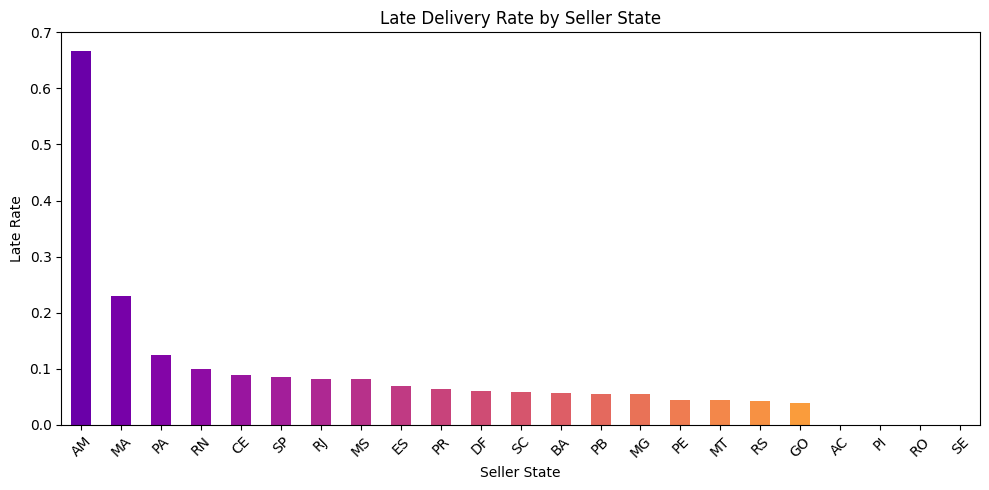

In [138]:
delay_by_seller_state = (
    dff.groupby('primary_seller_state')['is_late']
       .mean()
       .sort_values(ascending=False)
)

colors = cm.plasma(
    np.linspace(0.2, 0.9, len(delay_by_seller_state))
)

plt.figure(figsize=(10, 5))

delay_by_seller_state.plot(
    kind='bar',
    color=colors
)

plt.title('Late Delivery Rate by Seller State')
plt.ylabel('Late Rate')
plt.xlabel('Seller State')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('late_deliveries_by_seller_state.png', dpi=300, bbox_inches='tight')

plt.show()

### Insight 
- **What happened?** Late delivery rates vary substantially across seller states. **AM** has the highest observed late rate at approximately **67%**, followed by **MA (~23%)** and **PA (~13%)**, while several states have rates close to **0%**.
- **ML meaning:** `primary_seller_state` may provide useful geographic information for predicting late deliveries. However, the number of orders per state should also be considered because rates based on small samples may be unstable.
- **Business meaning:** Delivery performance differs across seller locations, suggesting that some geographic areas may face greater logistics challenges.
- **Action / recommendation:** Investigate high-delay seller states and evaluate carrier performance, transportation routes, fulfillment capacity, and delivery distances. Prioritize states with both high delay rates and sufficient order volume.
- **Limitation:** The chart shows the late rate but not the sample size for each state. High percentages based on few orders may be misleading, and the relationship is correlational rather than causal.

## Category Counts

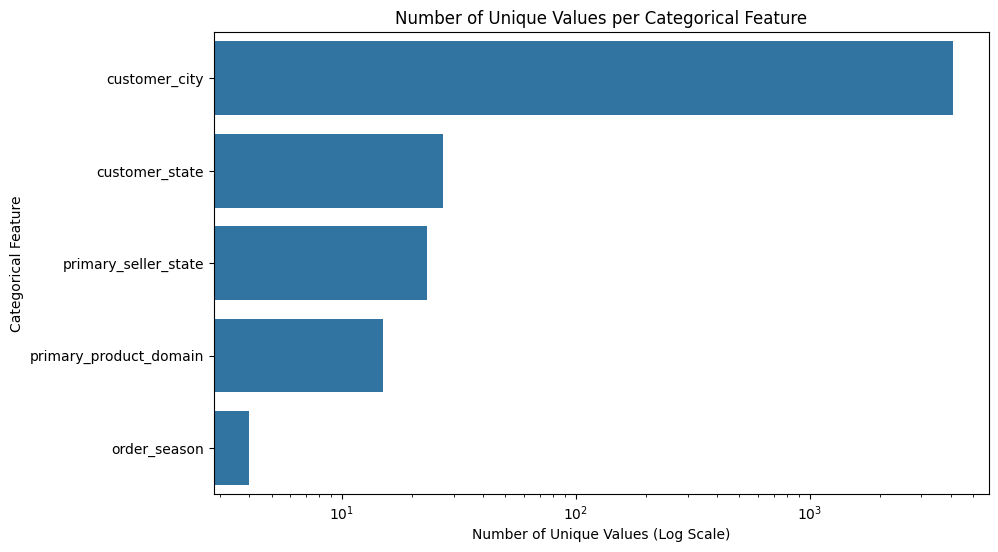

In [139]:
cat_cols = [
    "order_season",
    "customer_city",
    "customer_state",
    "primary_seller_state",
    "primary_product_domain"
]

unique_counts = dff[cat_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=unique_counts.values,
    y=unique_counts.index
)

plt.xscale("log")

plt.xlabel("Number of Unique Values (Log Scale)")
plt.ylabel("Categorical Feature")
plt.title("Number of Unique Values per Categorical Feature")
plt.savefig('categorical_variables.png', dpi=300, bbox_inches='tight')

plt.show()

### Insight 
- **What happened?** `customer_city` has by far the highest cardinality, with more than **4,000 unique values**, while `customer_state` and `primary_seller_state` have around **20–30 values**, `primary_product_domain` has around **15**, and `order_season` has only **4**.
- **ML meaning:** `customer_city` is a high-cardinality categorical feature. Direct one-hot encoding could create thousands of features and increase dimensionality. Lower-cardinality features such as state, product domain, and season are easier to encode.
- **Business meaning:** Customer location provides detailed geographic information, but city-level information may be difficult to manage efficiently at scale.
- **Action / recommendation:** Consider grouping cities into broader geographic regions or using frequency/target encoding instead of directly one-hot encoding thousands of cities. State-level features can provide a simpler geographic representation.
- **Limitation:** Cardinality alone does not indicate predictive power. Model-based feature importance should be used to determine whether `customer_city` actually contributes to predicting late orders.

# **ML Pipeline**

In [140]:
from sklearn.model_selection import train_test_split

## **Data Splitting**

In [141]:
X = dff.drop(columns=['is_late', 'order_id', 'customer_id' , 'customer_unique_id'])
y = dff["is_late"]

In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify =y)

## **Data Encoding And Feature Scaling**

In [143]:
X_train.head()

,order_month,order_season,order_weekday,order_hour,is_weekend,customer_order_seq,is_repeat_customer,expected_delivery_days,customer_city,customer_state,total_freight_value,num_items,num_distinct_products,num_distinct_sellers,total_payment_value,primary_seller_state,primary_product_domain
1236,7,Winter,1,10,0,0,0,16,niteroi,RJ,23.44,1.0,1.0,1.0,64.96,RS,Electronics & Technology
23207,7,Winter,5,19,1,0,0,19,votuporanga,SP,14.06,1.0,1.0,1.0,163.06,SP,Sports & Leisure
21241,1,Summer,1,16,0,0,0,33,pelotas,RS,16.50,1.0,1.0,1.0,122.40,SP,Home & Living
49010,7,Winter,2,19,0,0,0,29,rio de janeiro,RJ,73.32,4.0,1.0,1.0,204.92,SP,Home & Living
12523,2,Summer,4,23,0,0,0,27,belo horizonte,MG,42.50,2.0,1.0,1.0,160.30,SP,Home & Living


In [144]:
X_train.describe()

,order_month,order_weekday,order_hour,is_weekend,customer_order_seq,is_repeat_customer,expected_delivery_days,total_freight_value,num_items,num_distinct_products,num_distinct_sellers,total_payment_value
count,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000,78932.000000
mean,6.028125,2.757982,14.767192,0.229919,0.039515,0.033180,23.395340,22.850656,1.141945,1.037995,1.013391,160.905569
std,3.229742,1.965656,5.321187,0.420783,0.264014,0.179109,8.805843,21.901069,0.538912,0.224808,0.121377,222.156377
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,9.590000
25%,3.000000,1.000000,11.000000,0.000000,0.000000,0.000000,18.000000,13.860000,1.000000,1.000000,1.000000,61.990000
50%,6.000000,3.000000,15.000000,0.000000,0.000000,0.000000,23.000000,17.170000,1.000000,1.000000,1.000000,105.370000
75%,8.000000,4.000000,19.000000,0.000000,0.000000,0.000000,28.000000,24.120000,1.000000,1.000000,1.000000,177.150000
max,12.000000,6.000000,23.000000,1.000000,16.000000,1.000000,149.000000,1794.960000,20.000000,8.000000,5.000000,13664.080000


In [145]:
num_cols=X.select_dtypes('number').columns.to_list()
cat_cols=X.select_dtypes('category').columns.to_list()
print(num_cols)
print(cat_cols)

['order_month', 'order_weekday', 'order_hour', 'is_weekend', 'customer_order_seq', 'is_repeat_customer', 'expected_delivery_days', 'total_freight_value', 'num_items', 'num_distinct_products', 'num_distinct_sellers', 'total_payment_value']
['order_season', 'customer_city', 'customer_state', 'primary_seller_state', 'primary_product_domain']


In [146]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [147]:
print(X_train['customer_city'].nunique())

3847


since customer city has huge number of values I used frequency encoding

In [148]:

for col in ['customer_city']:
    freq = X_train[col].value_counts(normalize=True)

    X_train[col] = X_train[col].map(freq)
    X_test[col] = X_test[col].map(freq).fillna(0)

In [149]:
cat_cols.remove('customer_city')
cat_cols

['order_season',
 'customer_state',
 'primary_seller_state',
 'primary_product_domain']

In [150]:
print(X_train['primary_product_domain'].nunique())
print(X_train['primary_seller_state'].nunique())
print(X_train['customer_state'].nunique())

15
23
27


In [151]:
X_train = pd.get_dummies(X_train, columns=cat_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=cat_cols, dtype=int)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [152]:
display(X_train.head())
display(X_test.head())

,order_month,order_weekday,order_hour,is_weekend,customer_order_seq,is_repeat_customer,expected_delivery_days,customer_city,total_freight_value,num_items,...,primary_product_domain_Fashion,primary_product_domain_Food & Beverages,primary_product_domain_Health & Beauty,primary_product_domain_Home & Living,primary_product_domain_Industry & Agriculture,primary_product_domain_Marketplace & Services,primary_product_domain_Pet,primary_product_domain_Sports & Leisure,primary_product_domain_Travel,primary_product_domain_Other
1236,0.300916,-0.894354,-0.895894,-0.546411,-0.149671,-0.185254,-0.839827,0.008767,0.026910,-0.263393,...,0,0,0,0,0,0,0,0,0,0
23207,0.300916,1.140603,0.795468,1.830123,-0.149671,-0.185254,-0.499142,0.000621,-0.401383,-0.263393,...,0,0,0,0,0,0,0,1,0,0
21241,-1.556830,-0.894354,0.231681,-0.546411,-0.149671,-0.185254,1.090721,0.001837,-0.289972,-0.263393,...,0,0,0,1,0,0,0,0,0,0
49010,0.300916,-0.385615,0.795468,-0.546411,-0.149671,-0.185254,0.636475,0.069351,2.304438,5.303411,...,0,0,0,1,0,0,0,0,0,0
12523,-1.247205,0.631864,1.547185,-0.546411,-0.149671,-0.185254,0.409351,0.028100,0.897192,1.592208,...,0,0,0,1,0,0,0,0,0,0


,order_month,order_weekday,order_hour,is_weekend,customer_order_seq,is_repeat_customer,expected_delivery_days,customer_city,total_freight_value,num_items,...,primary_product_domain_Fashion,primary_product_domain_Food & Beverages,primary_product_domain_Health & Beauty,primary_product_domain_Home & Living,primary_product_domain_Industry & Agriculture,primary_product_domain_Marketplace & Services,primary_product_domain_Pet,primary_product_domain_Sports & Leisure,primary_product_domain_Travel,primary_product_domain_Other
25857,0.610540,-0.385615,0.607539,-0.546411,-0.149671,-0.185254,-1.294074,0.003319,-0.405949,-0.263393,...,0,0,1,0,0,0,0,0,0,0
6555,-0.318333,-1.403094,1.547185,-0.546411,-0.149671,-0.185254,-1.521197,0.007183,0.285803,-0.263393,...,0,0,0,0,0,0,0,0,0,0
54822,-1.247205,0.631864,-2.775186,-0.546411,-0.149671,-0.185254,0.750036,0.015266,-0.399100,-0.263393,...,0,0,0,0,0,0,0,1,0,0
26087,1.539413,0.631864,0.795468,-0.546411,-0.149671,-0.185254,-0.044896,0.005688,-0.207784,-0.263393,...,0,0,0,0,0,0,0,1,0,0
34356,1.229789,1.649342,0.231681,1.830123,-0.149671,-0.185254,0.750036,0.001850,0.052023,-0.263393,...,0,0,0,1,0,0,0,0,0,0


In [153]:
print(X_train.shape)
print(X_test.shape)

(78932, 82)
(19733, 82)


## **Modeling**

In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

In [155]:
models={
  'LogisticRegression':LogisticRegression(),
  'DecisionTreeClassifier':DecisionTreeClassifier(),
  'RandomForestClassifier':RandomForestClassifier(),
  'KNeighborsClassifier':KNeighborsClassifier(),
  'XGBClassifier': XGBClassifier()
}

In [156]:
models_balances={
    'LogisticRegression':LogisticRegression(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier()
}

In [157]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred=model.predict(X_test)
    y_pred_proba=model.predict_proba(X_test)[:, 1]

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1_Macro': f1_score(y_test, y_pred , average="macro"),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    },model

In [158]:
results=[]

for name,model in models.items():
  metrics,_=evaluate_model(model,X_train,y_train,X_test,y_test)
  metrics['Models']=name
  metrics['class_weight']='None'
  results.append(metrics)

for name,model in models_balances.items():
  metrics,_=evaluate_model(model,X_train,y_train,X_test,y_test)
  metrics['Models']=name
  metrics['class_weight']='balanced'
  results.append(metrics)

comparison_df=pd.DataFrame(results).sort_values('Recall', ascending=False)
comparison_df=comparison_df[['Models', 'class_weight', 'Accuracy', 'Precision', 'Recall', 'F1_Macro', 'ROC-AUC']]
comparison_df

,Models,class_weight,Accuracy,Precision,Recall,F1_Macro,ROC-AUC
1,DecisionTreeClassifier,None,0.864795,0.187889,0.212141,0.562722,0.566513
6,DecisionTreeClassifier,balanced,0.862515,0.181111,0.208307,0.559305,0.563522
4,XGBClassifier,None,0.920184,0.477273,0.067093,0.537924,0.771509
3,KNeighborsClassifier,None,0.914762,0.300341,0.056230,0.525000,0.624732
7,RandomForestClassifier,balanced,0.920995,0.522388,0.044728,0.520561,0.756006
2,RandomForestClassifier,None,0.920134,0.459854,0.040256,0.516149,0.757600
0,LogisticRegression,None,0.920489,0.166667,0.000639,0.479935,0.715077
5,LogisticRegression,balanced,0.920489,0.166667,0.000639,0.479935,0.715077


### Applying OverSampling Teq

In [159]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Before oversampling:", y_train.value_counts().to_dict())
print("After oversampling :", y_train_over.value_counts().to_dict())

Before oversampling: {0: 72671, 1: 6261}
After oversampling : {0: 72671, 1: 72671}


In [160]:
results_over = []

for name, model in models.items():
    metrics, _ = evaluate_model(model, X_train_over, y_train_over, X_test, y_test)
    metrics['Models'] = name
    metrics['class_weight'] = 'RandomOverSampler'
    results_over.append(metrics)

comparison_over_df = pd.DataFrame(results_over).sort_values('Recall', ascending=False)
comparison_over_df = comparison_over_df[['Models', 'class_weight', 'Accuracy', 'Precision', 'Recall', 'F1_Macro', 'ROC-AUC']]
comparison_over_df

c:\Users\Vista Store\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Models,class_weight,Accuracy,Precision,Recall,F1_Macro,ROC-AUC
0,LogisticRegression,RandomOverSampler,0.650129,0.139403,0.659425,0.501888,0.714887
4,XGBClassifier,RandomOverSampler,0.776111,0.199114,0.603195,0.583082,0.757612
3,KNeighborsClassifier,RandomOverSampler,0.780216,0.149469,0.377636,0.543206,0.623400
1,DecisionTreeClassifier,RandomOverSampler,0.871332,0.202686,0.212141,0.568645,0.570134
2,RandomForestClassifier,RandomOverSampler,0.916890,0.406484,0.104153,0.561043,0.759172


### Appling UnderSampling Teq

In [161]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(
    X_train,
    y_train
)

print("Before undersampling:", y_train.value_counts().to_dict())
print("After undersampling :", y_train_under.value_counts().to_dict())

Before undersampling: {0: 72671, 1: 6261}
After undersampling : {0: 6261, 1: 6261}


In [162]:
results_under = []

for name, model in models.items():
    metrics, _ = evaluate_model(model, X_train_under, y_train_under, X_test, y_test)
    metrics['Models'] = name
    metrics['class_weight'] = 'RandomUnderSampler'
    results_under.append(metrics)

comparison_under_df = pd.DataFrame(results_under).sort_values('Recall', ascending=False)
comparison_under_df = comparison_under_df[['Models', 'class_weight', 'Accuracy', 'Precision', 'Recall', 'F1_Macro', 'ROC-AUC']]
comparison_under_df

,Models,class_weight,Accuracy,Precision,Recall,F1_Macro,ROC-AUC
4,XGBClassifier,RandomUnderSampler,0.713222,0.172480,0.688818,0.548543,0.766907
2,RandomForestClassifier,RandomUnderSampler,0.723103,0.176109,0.677316,0.554077,0.767792
0,LogisticRegression,RandomUnderSampler,0.646683,0.137746,0.656869,0.499340,0.715038
3,KNeighborsClassifier,RandomUnderSampler,0.611970,0.123765,0.640256,0.475264,0.661432
1,DecisionTreeClassifier,RandomUnderSampler,0.623980,0.125112,0.624281,0.480936,0.624118


### Applying SMOTE

In [163]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 72671, 1: 6261}
After SMOTE : {0: 72671, 1: 72671}


In [164]:
results_smote = []

for name, model in models.items():
    metrics, _ = evaluate_model(model, X_train_smote, y_train_smote, X_test, y_test)
    metrics['Models'] = name
    metrics['class_weight'] = 'RandomUnderSampler'
    results_smote.append(metrics)

comparison_smote_df = pd.DataFrame(results_smote).sort_values('Recall', ascending=False)
comparison_smote_df = comparison_smote_df[['Models', 'class_weight', 'Accuracy', 'Precision', 'Recall', 'F1_Macro', 'ROC-AUC']]
comparison_smote_df

c:\Users\Vista Store\anaconda3\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Models,class_weight,Accuracy,Precision,Recall,F1_Macro,ROC-AUC
3,KNeighborsClassifier,RandomUnderSampler,0.694877,0.130269,0.501597,0.508965,0.641475
0,LogisticRegression,RandomUnderSampler,0.828308,0.175969,0.316294,0.564787,0.680128
1,DecisionTreeClassifier,RandomUnderSampler,0.848883,0.174552,0.242812,0.559813,0.571951
2,RandomForestClassifier,RandomUnderSampler,0.908478,0.356377,0.191054,0.600011,0.747490
4,XGBClassifier,RandomUnderSampler,0.912988,0.361818,0.127157,0.571105,0.757770


### Hyper Parameter Tuning

In [165]:
final_comparison = pd.concat([comparison_df, comparison_over_df, comparison_under_df, comparison_smote_df ], ignore_index=True)
final_comparison = final_comparison.sort_values('Recall', ascending=False)
final_comparison

,Models,class_weight,Accuracy,Precision,Recall,F1_Macro,ROC-AUC
13,XGBClassifier,RandomUnderSampler,0.713222,0.172480,0.688818,0.548543,0.766907
14,RandomForestClassifier,RandomUnderSampler,0.723103,0.176109,0.677316,0.554077,0.767792
8,LogisticRegression,RandomOverSampler,0.650129,0.139403,0.659425,0.501888,0.714887
15,LogisticRegression,RandomUnderSampler,0.646683,0.137746,0.656869,0.499340,0.715038
16,KNeighborsClassifier,RandomUnderSampler,0.611970,0.123765,0.640256,0.475264,0.661432
17,DecisionTreeClassifier,RandomUnderSampler,0.623980,0.125112,0.624281,0.480936,0.624118
9,XGBClassifier,RandomOverSampler,0.776111,0.199114,0.603195,0.583082,0.757612
18,KNeighborsClassifier,RandomUnderSampler,0.694877,0.130269,0.501597,0.508965,0.641475
10,KNeighborsClassifier,RandomOverSampler,0.780216,0.149469,0.377636,0.543206,0.623400
19,LogisticRegression,RandomUnderSampler,0.828308,0.175969,0.316294,0.564787,0.680128


### We will tune the hyperparameters of the XGBClassifier after applying undersampling to address class imbalance.

In [166]:
final_comparison = pd.concat([comparison_df, comparison_over_df, comparison_under_df, comparison_smote_df ], ignore_index=True)
final_comparison.to_csv("model_comparison.csv",index = False)

In [167]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_under, y_train_under)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='recall', verbose=2)

In [168]:
print (grid_search.best_estimator_)
print(grid_search.best_params_)
print(grid_search.best_score_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
0.7057986073041314


In [169]:
y_predict= grid_search.predict(X_test)
y_predict_prob = grid_search.predict_proba(X_test)[: ,1]


In [170]:
recall_score(y_test, y_predict )


0.6952076677316293

In [196]:
import joblib

# Save the best model
joblib.dump(grid_search.best_estimator_, 'best_model.pkl')

['best_model.pkl']

### Best Model Evaluation

In [195]:
result = {
        'Accuracy': accuracy_score(y_test, y_predict),
        'Precision': precision_score(y_test, y_predict),
        'Recall': recall_score(y_test, y_predict),
        'F1 Macro': f1_score(y_test, y_predict , average= 'macro'),
        'ROC-AUC': roc_auc_score(y_test, y_predict_prob)
    }

evaluation = pd.DataFrame([result]).T
evaluation.columns = ["Evaluation"]
evaluation

,Evaluation
Accuracy,0.722951
Precision,0.179006
Recall,0.695208
F1 Macro,0.556455
ROC-AUC,0.776644


### Confusion Matrix

In [172]:
from sklearn.metrics import confusion_matrix
cv = confusion_matrix(y_test , y_predict)
cv

array([[13178,  4990],
       [  477,  1088]])

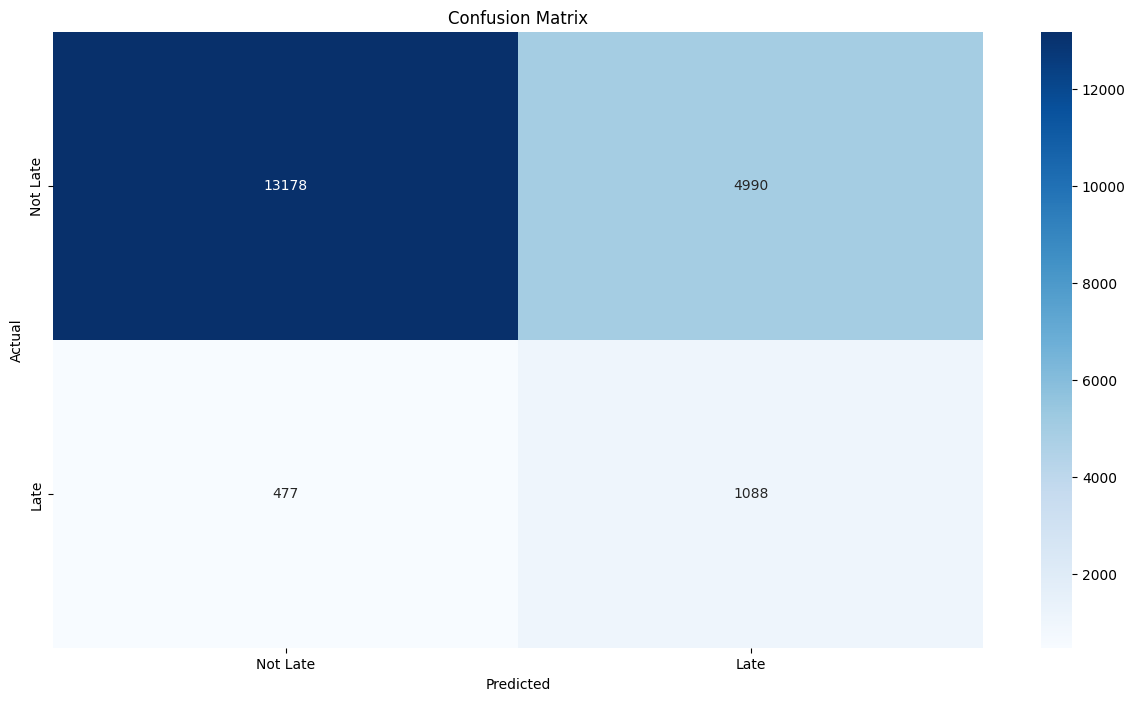

In [173]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    cv,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Late', 'Late'],
    yticklabels=['Not Late', 'Late']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight 
- **What happened?** Out of **19,733 test samples**, the model correctly identified **13,178 True Negatives** (Not Late) and **1,088 True Positives** (Late), while producing **4,990 False Positives** and **477 False Negatives**. This results in a **Recall of 69.5%** for late orders and a **Precision of 17.9%**.
- **ML meaning:** The model identifies approximately **70% of actual late orders**, but the low precision indicates that many orders predicted as late are actually not late. This suggests a trade-off between detecting the minority class and generating false alarms. Threshold tuning using a **Precision-Recall curve** or cost-sensitive learning could help find a better balance.
- **Business meaning:** Detecting approximately 70% of late orders can support proactive intervention and customer communication. However, the **4,990 false positives** could create substantial operational workload if every flagged order receives manual intervention.
- **Action / recommendation:** Use a **tiered alerting system** based on predicted probability. High-probability late orders can receive more intensive interventions, while moderate-risk orders can receive lower-cost actions such as automated tracking updates. The probability thresholds should be selected based on validation data and the business cost of false positives versus false negatives.
- **Limitation:** The confusion matrix evaluates the model at a **single decision threshold** and does not show the severity of each delay. A false negative could represent a one-day delay or a much longer delay, which may have very different business impacts.

### ROC Curve

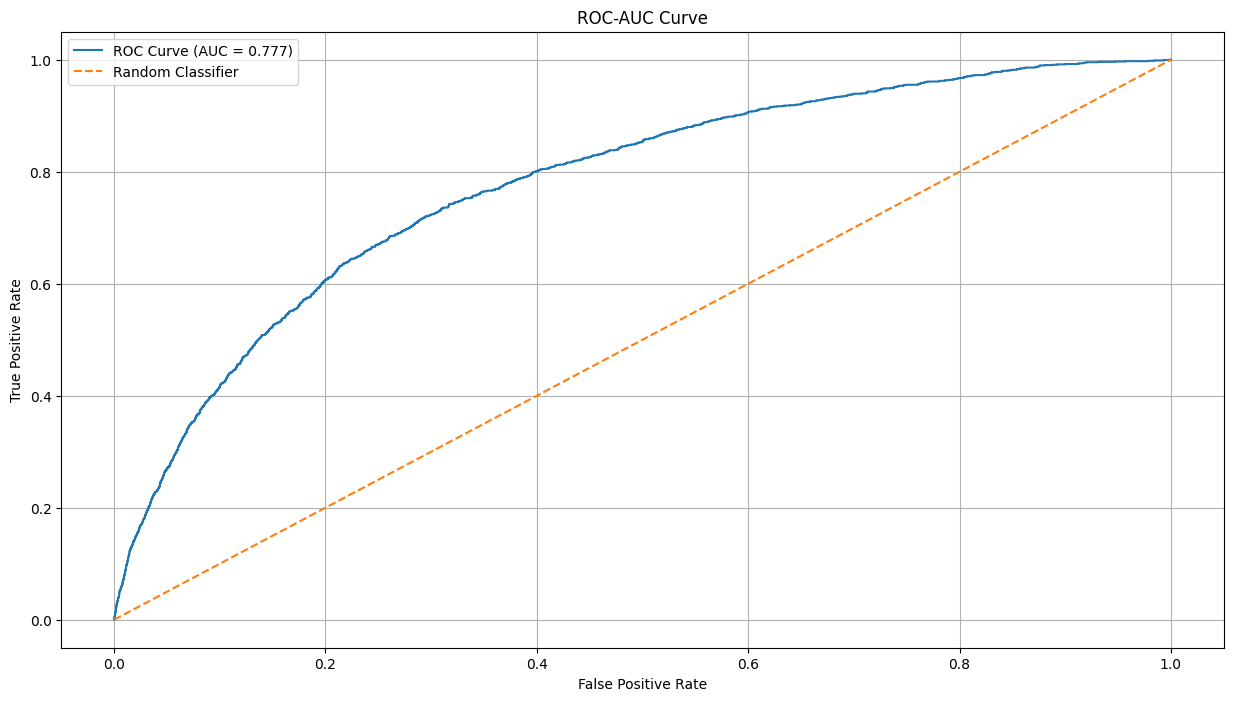

In [174]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_predict_prob)
roc_auc = roc_auc_score(y_test, y_predict_prob)

plt.figure(figsize=(15,8))
plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.grid()
plt.savefig('ROC_AUC.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight 
- **What happened?** The model achieves an **ROC-AUC of 0.777**, which is substantially above the random-classifier baseline of **0.50**. This indicates that the model has a useful ability to distinguish between late and on-time orders across different classification thresholds.
- **ML meaning:** The model has good overall ranking ability, but because the target is highly imbalanced (**~8% late orders**), ROC-AUC alone is not sufficient to evaluate minority-class performance. **PR-AUC** should also be considered because it focuses more directly on the trade-off between precision and recall for late orders.
- **Business meaning:** A ROC-AUC of **0.777** indicates that the model can generally assign higher risk scores to late orders than to on-time orders, making it potentially useful for ranking orders by delivery-risk level.
- **Action / recommendation:** Use the ROC and Precision-Recall curves together to identify an operating threshold that balances **late-order detection** with the number of false alerts. The selected threshold should reflect the business cost of missed delays versus unnecessary interventions.
- **Limitation:** ROC-AUC summarizes performance across all possible classification thresholds and may appear relatively strong on imbalanced datasets. Therefore, it should be interpreted together with **Precision, Recall, F1-score, and PR-AUC**, especially when late orders are the minority class.

### Feature Importance

In [175]:
feature_importance = pd.Series(
    grid_search.best_estimator_.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

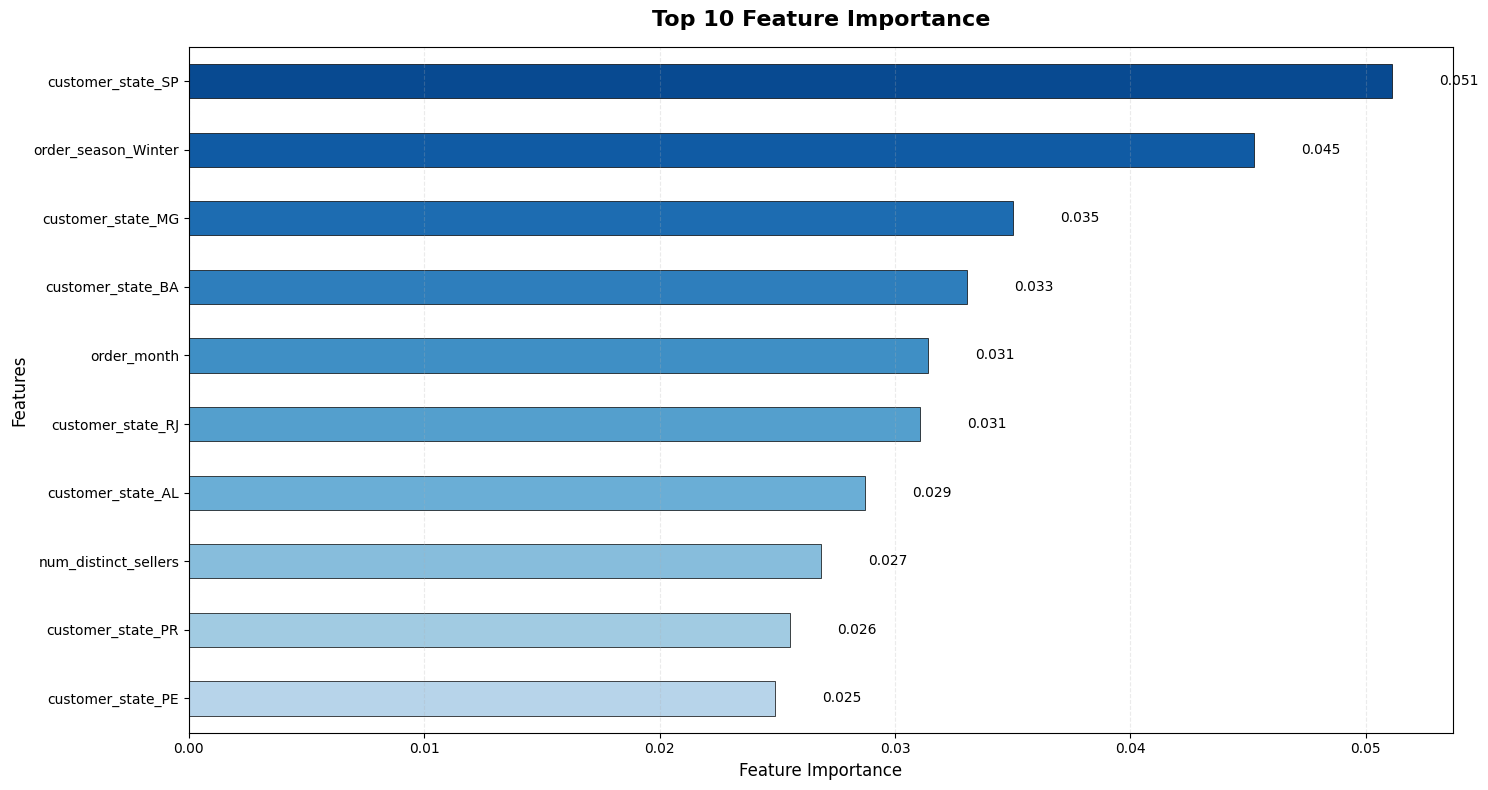

In [176]:
top_10 = feature_importance.head(10).sort_values()

plt.figure(figsize=(15, 8))

colors = cm.Blues(
    np.linspace(0.3, 0.9, len(top_10))
)

ax = top_10.plot(
    kind='barh',
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.title(
    'Top 10 Feature Importance',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Values on the bars
for i, value in enumerate(top_10):
    ax.text(
        value + 0.002,
        i,
        f'{value:.3f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.savefig('top_10_features.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
- **What happened?** Geographic and temporal features have the highest feature-importance scores. `customer_state_SP` is the most important feature (**0.051**), followed by `order_season_Winter` (**0.045**), `customer_state_MG` (**0.035**), `customer_state_BA` (**0.033**), `order_month` (**0.031**), `customer_state_RJ` (**0.031**), and `num_distinct_sellers` (**0.027**). This indicates that customer location, seasonality, and order structure contribute substantially to the model's predictions.
- **ML meaning:** Geographic and temporal features provide strong predictive signals for the model. This suggests that feature engineering should explore richer spatial and logistical relationships, such as seller-to-customer state pairs, geographic distance, and interstate versus intrastate delivery indicators.
- **Business meaning:** Customer location and seasonal patterns appear to be important when estimating delivery-delay risk. This suggests that logistics performance may vary across different geographic markets and periods, while multi-seller orders may also provide additional predictive information.
- **Action / recommendation:** Investigate delivery performance by geographic route and season, and consider using route-level features and dynamic delivery estimates in future modeling. Multi-seller orders can also be monitored as a potentially higher-risk order characteristic.
- **Limitation:** Feature importance shows how much the model relies on a feature for making predictions, but it does **not indicate the direction of its effect**. For example, `customer_state_SP` being highly important does not mean that being in SP increases or decreases late-delivery probability. SHAP values or partial-dependence analysis would be needed to investigate directional effects.

# **Business Insights & Recommendations**


## Business Insights Analysis

In [177]:
late_orders = dff [dff["is_late" ] == 1]
late_orders.sample(3)

,order_id,customer_id,order_month,order_season,order_weekday,order_hour,is_late,is_weekend,customer_order_seq,is_repeat_customer,...,customer_unique_id,customer_city,customer_state,total_freight_value,num_items,num_distinct_products,num_distinct_sellers,total_payment_value,primary_seller_state,primary_product_domain
2378,1ef47fb13ee9044b5e5aa3bd388755de,c1f326c1584e139615e3ba4ae4d23760,3,Autumn,3,10,1,0,0,0,...,1bc28b08fa28f7f12d4373d7ee73978b,itanhandu,MG,18.72,1.0,1.0,1.0,138.62,SP,Home & Living
36305,da81fbc27b55e0f3d2813cf2078dc780,9cb739dc712ebd193e4eb94f3aeb8d20,11,Spring,1,21,1,0,0,0,...,9770456b4233cdf2363287ca2295650a,rio das ostras,RJ,56.35,1.0,1.0,1.0,1755.35,SP,Other
34912,58274272cfde0e71c0ee61eaee5a60e1,b9cac70fb717faca4acaca1b59ba4e44,8,Winter,1,22,1,0,0,0,...,1c82e048ed0403e0651365bc7fcaa7e7,guarulhos,SP,8.14,1.0,1.0,1.0,133.14,SP,Fashion


In [178]:
late_orders.describe()

,order_month,order_weekday,order_hour,is_late,is_weekend,customer_order_seq,is_repeat_customer,expected_delivery_days,total_freight_value,num_items,num_distinct_products,num_distinct_sellers,total_payment_value
count,7826.000000,7826.000000,7826.000000,7826.0,7826.000000,7826.000000,7826.000000,7826.000000,7826.000000,7826.000000,7826.000000,7826.000000,7826.000000
mean,5.754281,2.654868,14.929338,1.0,0.213775,0.033989,0.030284,21.609890,24.624337,1.113212,1.021595,1.002300,172.717976
std,3.557371,1.974560,5.378717,0.0,0.409996,0.215963,0.171378,7.939822,22.833002,0.501715,0.158003,0.047906,236.842676
min,1.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,1.000000,1.000000,14.290000
25%,3.000000,1.000000,11.000000,1.0,0.000000,0.000000,0.000000,18.000000,15.100000,1.000000,1.000000,1.000000,66.342500
50%,5.000000,2.000000,15.000000,1.0,0.000000,0.000000,0.000000,22.000000,18.055000,1.000000,1.000000,1.000000,112.235000
75%,9.000000,4.000000,19.000000,1.0,0.000000,0.000000,0.000000,26.000000,26.427500,1.000000,1.000000,1.000000,188.165000
max,12.000000,6.000000,23.000000,1.0,1.000000,7.000000,1.000000,69.000000,711.330000,21.000000,4.000000,2.000000,6922.210000


In [179]:
late_orders["order_month"].value_counts()/late_orders.shape[0]

order_month
3     0.209302
2     0.140813
11    0.133274
8     0.102096
5     0.087401
4     0.069256
1     0.062228
12    0.059034
7     0.052262
10    0.030667
9     0.027600
6     0.026067
Name: count, dtype: float64

In [180]:
late_orders["order_season"].value_counts()/late_orders.shape[0]

order_season
Autumn    0.365960
Summer    0.262075
Spring    0.191541
Winter    0.180424
Name: count, dtype: float64

In [181]:
late_orders["is_repeat_customer"].value_counts()/late_orders.shape[0]

is_repeat_customer
0    0.969716
1    0.030284
Name: count, dtype: float64

In [182]:
late_orders["is_weekend"].value_counts()/late_orders.shape[0]

is_weekend
0    0.786225
1    0.213775
Name: count, dtype: float64

In [183]:
late_orders["num_items"].value_counts()/late_orders.shape[0]

num_items
1.0     0.919755
2.0     0.062612
3.0     0.010222
4.0     0.003578
6.0     0.002044
5.0     0.001661
21.0    0.000128
Name: count, dtype: float64

In [184]:
late_orders["is_repeat_customer"].value_counts()/late_orders.shape[0]

is_repeat_customer
0    0.969716
1    0.030284
Name: count, dtype: float64

In [185]:
late_orders["num_distinct_products"].value_counts()/late_orders.shape[0]

num_distinct_products
1.0    0.980194
2.0    0.018145
3.0    0.001533
4.0    0.000128
Name: count, dtype: float64

In [186]:
late_orders["num_distinct_sellers"].value_counts()/late_orders.shape[0]

num_distinct_sellers
1.0    0.9977
2.0    0.0023
Name: count, dtype: float64

In [187]:
def con (x):
    if x <= 20 :
        return "<= 20"
    elif x<=40 :
        return "< =40"
    else:
        return "<= 60"

expected_delivery_days_cat = dff["expected_delivery_days"].apply(con)

In [188]:
expected_delivery_days_cat.value_counts()/expected_delivery_days_cat.shape[0]

expected_delivery_days
< =40    0.600233
<= 20    0.365226
<= 60    0.034541
Name: count, dtype: float64

In [189]:
def con (x):
    if x <= 100 :
        return "Less Than 100"
    else :
        return "Grater Than 100"


total_freight_cat = dff["total_freight_value"].apply(con)

In [190]:
total_freight_cat.value_counts()/total_freight_cat.shape[0]

total_freight_value
Less Than 100      0.988821
Grater Than 100    0.011179
Name: count, dtype: float64

In [191]:
def con (x):
    if x <= 200 :
        return "Less Than 200"
    elif x <= 400:
        return "Less Than 400"
    else :
        return "grater than 400"

total_pay_cat = dff["total_payment_value"].apply(con)

In [192]:
total_pay_cat.value_counts()/total_pay_cat.shape[0]

total_payment_value
Less Than 200      0.796331
Less Than 400      0.142401
grater than 400    0.061268
Name: count, dtype: float64

## Business Insights

### 1. Seasonal concentration of late orders

* **Autumn** accounts for the highest share of late orders (**36.6%**), followed by **Summer (26.2%)**.
* **Spring (19.2%)** and **Winter (18.5%)** contribute smaller shares.
* This indicates that delivery delays are more concentrated during the **Autumn and Summer seasons**.

### 2. High concentration of late orders in March

* **March** represents the largest share of late orders (**20.9%**).
* February (**14.7%**) and November (**13.3%**) also show relatively high shares.
* This suggests that certain months may require additional operational attention and capacity planning.

### 3. Most late orders are from non-repeat customers

* Around **97.0%** of late orders are associated with **non-repeat customers**, while only **3.0%** come from repeat customers.
* This suggests that late orders are mainly occurring among first-time customers within this dataset.

### 4. Most late orders occur on weekdays

* Approximately **78.6%** of late orders occur on **weekdays**, compared with **21.4%** on weekends.
* Therefore, delays are not primarily concentrated around weekend orders.

### 5. Late orders are mostly simple orders

* Around **92.0%** of late orders contain only **one item**.
* Similarly, approximately **98.1%** involve only **one distinct product**, and **99.8%** involve only **one seller**.
* This indicates that late delivery is not mainly associated with complex multi-item or multi-seller orders.

### 6. Most late orders have relatively short estimated delivery periods

* Around **60.0%** of late orders have an estimated delivery period of **20 days or less**.
* Approximately **35.2%** have an estimated delivery period between **21 and 40 days**.
* Only **4.5%** have an estimated delivery period above **40 days**.
* This suggests that many delays occur even when the expected delivery window is relatively short.

### 7. Freight costs are usually below 100

* Approximately **98.9%** of late orders have total freight costs below **100**, while only **1.1%** exceed 100.
* Therefore, high freight cost is not a common characteristic of late orders.

### 8. Most late orders have relatively low payment values

* Around **79.6%** of late orders have total payment values below **200**.
* **14.2%** fall between **200 and 400**, while only **6.1%** exceed **400**.
* This indicates that late deliveries are mostly associated with lower-value orders rather than high-value transactions.



##  Business Recommendations


### 1. Increase operational capacity during high-risk seasons

* Increase logistics capacity and delivery resources during **Autumn and Summer**.
* Prepare additional transportation and fulfillment capacity ahead of high-delay periods.

### 2. Focus on March and other high-delay months

* Conduct a detailed review of operations during **March**, which has the highest share of late orders.
* Use historical demand and delivery data to anticipate potential bottlenecks before these months.

### 3. Improve delivery-time estimation

* Since a large proportion of late orders have estimated delivery periods of **20 days or less**, review whether delivery estimates are too optimistic.
* Use historical delivery performance to create more realistic estimated delivery dates.

### 4. Prioritize logistics performance over order complexity

* Since most late orders involve **one item, one product, and one seller**, reducing order complexity alone is unlikely to eliminate delays.
* Focus instead on **shipping, transportation, fulfillment, and delivery processes**.

### 5. Monitor first-time customer orders

* Since approximately **97% of late orders involve non-repeat customers**, closely monitor the first-order delivery experience.
* Improving first-order delivery reliability may help reduce customer dissatisfaction and improve future retention.

### 6. Track delivery performance by month and season

* Build monthly and seasonal delivery-performance dashboards.
* Set alerts for periods where the late-order rate exceeds the expected threshold.

### 7. Use customer and order characteristics for targeted monitoring

* Combine features such as **customer location, seller location, estimated delivery time, season, and order characteristics** to identify orders with higher potential delivery risk.
* This can support proactive intervention before an order becomes significantly delayed.



## Limitations

- The analysis is descriptive and identifies patterns in late orders, but it does not establish causal relationships.
- The observed patterns may be influenced by other factors that are not included in the analysis.
- The distribution of late orders is not sufficient to conclude that a specific feature directly causes delivery delays.
- Further statistical analysis and predictive modeling are needed to validate these relationships.

## 🌟 Thank You! 

[🔗 Visit My GitHub](https://github.com/yourusername)